# Детектив фроду — Case #3, Genesis Analytics Camp 3.0  
Непоп Олександр

**Мета:** знайти підозрілі партнерські мережі, обґрунтувати кожну гіпотезу щонайменше
двома незалежними показниками, визначити тип фроду та запропонувати спосіб контролю.

**Інструменти:** DuckDB для великих агрегацій, pandas для невеликих зведень,
matplotlib і seaborn для графіків.

**Послідовність аналізу:** `ГІПОТЕЗА → ПЕРЕВІРКА ВІДНОСНО PPC → ЩОНАЙМЕНШЕ ДВА СИГНАЛИ → БІЗНЕС-ДІЯ`.

> `ppc` — наша внутрішня закупівля, де, за умовою кейсу, фроду немає. Це основна
> база для порівняння. `organic` використовую обережно, оскільки такі користувачі
> спочатку можуть бути більш мотивованими. Порівнюю CPA з CPA, CPS із CPS та,
> де можливо, однакові країни й місяці.

## 0. Налаштування середовища

In [1]:
# Імпорти
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Відображення pandas — щоб широкі зведення не обрізались
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Стиль графіків
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['figure.dpi'] = 110

print('duckdb', duckdb.__version__, '| pandas', pd.__version__)

duckdb 1.5.4 | pandas 3.0.2


In [2]:
# Портативні шляхи (без хардкоду C:/Users/... — працює на обох машинах)
from pathlib import Path

# Знаходимо корінь проєкту навіть якщо Jupyter відкрито з вкладеної теки.
PROJECT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / 'case3_antifraud.ipynb').exists()),
    Path.cwd(),
)
DATA    = PROJECT / 'data'      # сирі CSV
PARQUET = PROJECT / 'parquet'   # основний формат даних для відтворення

PARQUET.mkdir(exist_ok=True)
print('PROJECT :', PROJECT)
print('PARQUET :', PARQUET)
print('CSV fallback:', DATA if DATA.exists() else 'не потрібен — використовуємо Parquet')

PROJECT : <repository-root>
PARQUET : <repository-root>/parquet
CSV fallback: не потрібен — використовуємо Parquet


In [3]:
# Підключення до DuckDB (in-memory) + хелпер для запитів
con = duckdb.connect()          # без файлу: база живе в памʼяті процесу

def q(sql: str) -> pd.DataFrame:
    """Виконати SQL у DuckDB і повернути результат як pandas DataFrame."""
    return con.sql(sql).df()

# приклад: q("SELECT 42 AS answer")
q("SELECT 'DuckDB підключено' AS status")

,status
0,DuckDB підключено


## 1. Конвертація CSV у Parquet для швидшої роботи

In [4]:
# Мапа: імʼя parquet -> вихідний CSV
files = {
    'registrations': 'registrations.csv',
    'activity_log':  'activity_log-002.csv',
    'payments':      'payments.csv',
    'credits':       'credits.csv',
}

for name, csv in files.items():
    out = PARQUET / f'{name}.parquet'
    if out.exists():
        print(f'✓ {name}.parquet вже існує — пропускаю')
        continue
    src = DATA / csv
    if not src.exists():
        raise FileNotFoundError(
            f'Не бачу {out.name}. Завантаж Parquet командою з README: '
            f'python scripts/download_data.py'
        )
    print(f'... конвертую {csv} → {name}.parquet')
    con.execute(f"""
        COPY (SELECT * FROM read_csv_auto('{src.as_posix()}'))
        TO '{out.as_posix()}' (FORMAT parquet)
    """)
    print(f'✓ готово: {name}.parquet ({out.stat().st_size/1e6:.0f} МБ)')

✓ registrations.parquet вже існує — пропускаю
✓ activity_log.parquet вже існує — пропускаю
✓ payments.parquet вже існує — пропускаю
✓ credits.parquet вже існує — пропускаю


## 2. Короткі назви таблиць і очищені подання

In [5]:
# Джерельні та очищені views. Сирі таблиці не змінюємо.
con.execute(f"""
CREATE OR REPLACE VIEW reg AS
    SELECT * FROM read_parquet('{(PARQUET/"registrations.parquet").as_posix()}')
""")

con.execute(f"""
CREATE OR REPLACE VIEW act_raw AS
    SELECT f0_ AS id_user, date_start, duration
    FROM read_parquet('{(PARQUET/"activity_log.parquet").as_posix()}')
""")
con.execute("""
CREATE OR REPLACE VIEW act AS
    SELECT DISTINCT id_user, date_start, duration FROM act_raw
""")

con.execute(f"""
CREATE OR REPLACE VIEW pay_raw AS
    SELECT * FROM read_parquet('{(PARQUET/"payments.parquet").as_posix()}')
""")
con.execute("""
CREATE OR REPLACE VIEW pay AS
    SELECT DISTINCT * FROM pay_raw
""")

con.execute(f"""
CREATE OR REPLACE VIEW cred_raw AS
    SELECT f0_ AS id_user, date_created, credits_changed, credit_type
    FROM read_parquet('{(PARQUET/"credits.parquet").as_posix()}')
""")
con.execute("""
CREATE OR REPLACE VIEW cred AS
    SELECT DISTINCT * FROM cred_raw
""")

print("views: reg; act_raw → act; pay_raw → pay; cred_raw → cred")
display(q("SELECT * FROM reg LIMIT 5"))
display(q("SELECT * FROM act LIMIT 5"))
display(q("SELECT * FROM pay LIMIT 5"))
display(q("SELECT * FROM cred LIMIT 5"))


views: reg; act_raw → act; pay_raw → pay; cred_raw → cred


,id_user,id_metauser,email,date_created,date_visit,network,traffic_type,country,device_os,user_agent,cost
0,173981320,1852581308,d9dad2c3@yahoo.com,2026-06-22 10:42:39,2026-06-22 10:37:46.301490,ppc,ppc,IN,Android,mozilla/5.0 (linux; android 10; k) applewebkit...,1.088
1,173983827,1852660774,1dffc385@gmail.com,2026-06-22 11:07:53,2026-06-22 11:02:20.147404,ppc,ppc,MG,Android,mozilla/5.0 (linux; android 10; k) applewebkit...,2.190
2,173984834,1783939722,943cc86f@yahoo.com,2026-06-22 11:14:58,2026-06-22 11:13:31.890268,427,cpa,US,iOS,NaN,11.100
3,173985959,1671387119,5e59ce2c@gmail.com,2026-06-22 11:25:37,2026-06-22 11:23:12.261346,ppc,ppc,RS,Android,mozilla/5.0 (linux; android 16; 25100ra69g bui...,0.562
4,173988419,1852791205,ad842b07@hotmail.com,2026-06-22 11:45:09,2026-06-22 11:40:24.943440,ppc,ppc,US,Android,mozilla/5.0 (linux; android 15; infinix x6728 ...,0.437


,id_user,date_start,duration
0,145085754,2026-01-16 09:11:42.884798,193
1,143038895,2026-02-18 11:26:47.164480,646
2,143118467,2026-01-16 22:16:40.057136,133
3,144787154,2026-01-19 04:27:47.562939,171
4,146462527,2026-01-28 08:16:56.000000,145


,id_user,date_created,amount,status,country_payment,chargeback_date
0,146771763,2026-05-06 03:09:16,45,success,FRA,NaT
1,163923306,2026-05-06 03:18:19,125,success,USA,NaT
2,164624773,2026-05-06 03:21:02,150,fail,USA,NaT
3,164187831,2026-05-06 03:27:43,65,fail,BRA,NaT
4,163902906,2026-05-06 04:47:00,270,success,USA,NaT


,id_user,date_created,credits_changed,credit_type
0,173099821,2026-07-12 09:40:59,10,other
1,171438820,2026-06-11 12:26:48,10,2
2,167157596,2026-05-27 17:01:15,10,3
3,166075426,2026-07-05 20:57:32,10,other
4,172232464,2026-07-21 16:25:06,10,other


У даних є 14 партнерських агенцій. `ppc` — трафік, який компанія закуповує
самостійно, а `organic` — користувачі, які знайшли продукт без платної реклами.
Тому `ppc` використовую як головну базу для порівняння з агенціями. `organic`
не беру за еталон: такі користувачі можуть від початку бути більш зацікавленими
в продукті.

## 3. Перевірка якості даних

- повні дублікати рядків;
- пропуски у ключових полях (`date_visit`, `country`, `user_agent`, `email`);
- наявність усіх `id_user` з оплат, кредитів та активності у таблиці реєстрацій;
- часові аномалії, зокрема `date_visit > date_created`.

In [6]:
# 1. Повні дублікати у сирих таблицях.
tables = ["reg", "act_raw", "pay_raw", "cred_raw"]
duplicate_queries = []
for table in tables:
    duplicate_queries.append(f"""
        SELECT '{table}' AS table_name,
               COUNT(*) AS total_rows,
               (SELECT COUNT(*) FROM (SELECT DISTINCT * FROM {table})) AS unique_rows,
               COUNT(*) - (SELECT COUNT(*) FROM (SELECT DISTINCT * FROM {table}))
                   AS full_duplicate_rows
        FROM {table}
    """)
display(q("\nUNION ALL\n".join(duplicate_queries)))

# 2. NULL у ключових полях registrations.
display(q("""
SELECT COUNT(*) AS total_rows,
       SUM(date_visit IS NULL) AS null_date_visit,
       SUM(country IS NULL) AS null_country,
       SUM(user_agent IS NULL) AS null_user_agent,
       SUM(email IS NULL) AS null_email
FROM reg
"""))

# 3. Дочірні записи без registrations.
display(q("""
SELECT 'pay' AS source_table, COUNT(*) AS rows_without_reg_user,
       COUNT(DISTINCT p.id_user) AS users_without_reg
FROM pay p LEFT JOIN reg r USING (id_user)
WHERE p.id_user IS NOT NULL AND r.id_user IS NULL
UNION ALL
SELECT 'cred', COUNT(*), COUNT(DISTINCT c.id_user)
FROM cred c LEFT JOIN reg r USING (id_user)
WHERE c.id_user IS NOT NULL AND r.id_user IS NULL
UNION ALL
SELECT 'act_raw', COUNT(*), COUNT(DISTINCT a.id_user)
FROM act_raw a LEFT JOIN reg r USING (id_user)
WHERE a.id_user IS NOT NULL AND r.id_user IS NULL
"""))

# 4. Неконсистентні дати.
display(q("""
SELECT
  (SELECT COUNT(*) FROM reg WHERE date_visit > date_created) AS visit_after_registration,
  (SELECT COUNT(*) FROM pay WHERE chargeback_date < date_created) AS chargeback_before_payment,
  (SELECT COUNT(*) FROM pay WHERE chargeback_date IS NOT NULL) AS all_chargebacks
"""))

# 5. Покриття activity_log за місяцем реєстрації.
activity_coverage_dq = q("""
WITH session_users AS (SELECT DISTINCT id_user FROM act)
SELECT CAST(date_trunc('month', r.date_created) AS DATE) AS registration_month,
       COUNT(*) AS ppc_regs,
       ROUND(AVG(CASE WHEN s.id_user IS NOT NULL THEN 1.0 ELSE 0.0 END), 3)
           AS ppc_any_session_rate
FROM reg r
LEFT JOIN session_users s USING (id_user)
WHERE r.network = 'ppc'
GROUP BY 1 ORDER BY 1
""")
display(activity_coverage_dq)


,table_name,total_rows,unique_rows,full_duplicate_rows
0,reg,8049602,8049602,0
1,act_raw,96303584,63914103,32389481
2,pay_raw,2301720,2301691,29
3,cred_raw,35658710,35560418,98292


,total_rows,null_date_visit,null_country,null_user_agent,null_email
0,8049602,0.000,"1,561.000","4,918,274.000",0.000


,source_table,rows_without_reg_user,users_without_reg
0,pay,0,0
1,cred,0,0
2,act_raw,2173,1138


,visit_after_registration,chargeback_before_payment,all_chargebacks
0,129,2434,7925


,registration_month,ppc_regs,ppc_any_session_rate
0,2026-01-01,400847,0.871
1,2026-02-01,320772,0.869
2,2026-03-01,463697,0.000
3,2026-04-01,466615,0.000
4,2026-05-01,547764,0.844
5,2026-06-01,536019,0.817
6,2026-07-01,382194,0.821


**Висновок щодо якості даних**

- У `activity_log` є масові повні дублікати, тому всі поведінкові показники
  рахую на очищеному поданні `act = DISTINCT`.
- У `payments` та `credits` також є невелика кількість дублів; у подальших
  розрахунках використовую очищені `pay` і `cred`.
- Для реєстрацій березня–квітня покриття `activity_log` у чистого `ppc`
  дорівнює нулю. Це пропуск даних, а не ознака фроду, тому ці когорти не
  включаю до показників сесій та утримання.
- Частина `chargeback_date` раніша за дату відповідної оплати. Згідно з
  уточненням авторки кейсу, нас цікавить передусім сам факт повернення коштів.
  Факт і сума chargeback придатні для порівняння мереж, але часовий проміжок
  від оплати до повернення у цих рядках ненадійний.
- `user_agent` майже повністю відсутній у партнерському трафіку. Це обмеження
  джерела окремо враховую у блоці 8.

In [7]:
display(q("""
SELECT
network, 
traffic_type, 
count(*) as regs, 
count(distinct id_metauser) as metausers,
regs / metausers as regs_per_metauser,
round (avg  ("cost"), 2) as avg_cost,
avg(CASE WHEN cost IS NULL THEN 1 ELSE 0 END) as avg_cost_with_nulls,
MIN ("cost") as min_cost,
MAX ("cost") as max_cost,

FROM reg
group by 1, 2
order by regs_per_metauser desc

"""))

,network,traffic_type,regs,metausers,regs_per_metauser,avg_cost,avg_cost_with_nulls,min_cost,max_cost
0,organic,organic,1156766,805502,1.436,NaN,1.000,NaN,NaN
1,833,cpa,1114202,920470,1.210,7.630,0.658,0.740,22.200
2,413,cpa,184394,157939,1.168,19.110,0.225,0.370,88.800
3,427,cpa,232251,199937,1.162,18.480,0.226,0.740,333.000
4,ppc,ppc,3117908,2696530,1.156,6.940,0.006,0.000,738.550
5,897,cpa,153366,139047,1.103,13.050,0.371,0.081,44.400
6,1002,cpa,108535,98951,1.097,382.250,0.941,5.180,697.820
7,1052,cpa,95788,89500,1.070,150.110,0.866,2.220,888.000
8,719,cpa,123232,116487,1.058,19.140,0.374,3.700,370.000
9,612,cpa,111675,106562,1.048,502.670,0.979,11.100,777.000


## 4. Первинний огляд мереж

На цьому етапі формую перші гіпотези, але ще не роблю висновків про фрод.

1. `regs_per_metauser` у середньому не показує великої різниці від `ppc`.
   Оскільки агенція може домішувати фрод невеликими частинами, далі перевірю
   не лише середнє, а й крайні значення та концентрацію повторних реєстрацій.
2. Великий розкид `avg_cost` може пояснюватися моделлю оплати CPA/CPS і
   складом країн. Спочатку класифікую мережі, щоб не порівнювати різні
   бізнес-моделі між собою.
3. `NULL` і нульова вартість мають різний зміст, тому не об'єдную їх
   автоматично під час очищення.

## 5. Класифікація мереж: CPA vs CPS




In [8]:
# класифікація мереж за моделлю оплати
display(q("""
WITH payers AS (                      
    SELECT DISTINCT id_user
    FROM pay
    WHERE status = 'success'
)
SELECT
    reg.network,
    reg.traffic_type,
    count(*) AS regs,

    -- частка реєстрацій, за які ми заплатили партнеру:

    round(avg(CASE WHEN reg."cost" IS NOT NULL THEN 1 ELSE 0 END), 3) AS pct_costed,

    -- серед costed-юзерів — яка частка реальних платників:

    round(
        count(*) FILTER (WHERE reg."cost" IS NOT NULL AND payers.id_user IS NOT NULL)
        / nullif(count(*) FILTER (WHERE reg."cost" IS NOT NULL), 0)
    , 3)  AS payrate_among_costed

FROM reg
LEFT JOIN payers ON reg.id_user = payers.id_user
GROUP BY reg.network, reg.traffic_type
ORDER BY payrate_among_costed DESC
"""))   

,network,traffic_type,regs,pct_costed,payrate_among_costed
0,889,cpa,62118,0.017,1.000
1,612,cpa,111675,0.021,0.835
2,1002,cpa,108535,0.059,0.687
3,1052,cpa,95788,0.134,0.199
4,427,cpa,232251,0.774,0.060
5,413,cpa,184394,0.775,0.058
6,719,cpa,123232,0.626,0.049
7,730,cpa,137252,0.720,0.049
8,897,cpa,153366,0.629,0.044
9,ppc,ppc,3117908,0.994,0.026


In [9]:
display(q("""
    SELECT
        country,
        COUNT(*) AS regs
    FROM reg
    WHERE network = '1052'
    GROUP BY country
    ORDER BY regs DESC
"""))

,country,regs
0,US,65510
1,GB,12049
2,AU,7268
3,CA,7216
4,NZ,1110
...,...,...
139,TJ,1
140,SC,1
141,MO,1
142,GE,1


CPS = {889, 612, 1002}  
CPA = {427, 413, 730, 719, 897, 833, 303, 523, 911, 851, ppc}

`1052` — окремий випадок. Частка платників близько 20%, що може відповідати
дорогому CPA-трафіку з Tier-1 країн. Водночас мережа має близько $1.5 млн
втрат через chargeback, тому платіжний ризик перевіряю окремо у блоці 10.

In [10]:
# Попередня таблиця показників якості.
# Показник сесій рахую лише для когорт, де activity_log має достатнє покриття у чистому ppc.
display(q("""
WITH session_users AS (
    SELECT DISTINCT id_user
    FROM act
),
payers AS (
    SELECT DISTINCT id_user
    FROM pay
    WHERE status = 'success'
),
spenders AS (
    SELECT DISTINCT id_user
    FROM cred
),
ppc_cohort_coverage AS (
    SELECT
        date_trunc('month', r.date_created) AS registration_month,
        AVG(CASE WHEN s.id_user IS NOT NULL THEN 1.0 ELSE 0.0 END)
            AS ppc_any_session_rate
    FROM reg r
    LEFT JOIN session_users s USING (id_user)
    WHERE r.network = 'ppc'
    GROUP BY 1
)
SELECT
    r.network,
    r.traffic_type,
    COUNT(*) AS regs,

    COUNT(*) FILTER (
        WHERE coverage.ppc_any_session_rate >= 0.10
    ) AS regs_with_valid_activity_coverage,

    ROUND(
        AVG(
            CASE
                WHEN coverage.ppc_any_session_rate >= 0.10
                THEN CASE WHEN sessions.id_user IS NULL THEN 1.0 ELSE 0.0 END
                ELSE NULL
            END
        ),
        3
    ) AS pct_no_session_valid_cohorts,

    ROUND(
        AVG(CASE WHEN payers.id_user IS NOT NULL THEN 1.0 ELSE 0.0 END),
        3
    ) AS cr_pay,

    ROUND(
        AVG(CASE WHEN spenders.id_user IS NULL THEN 1.0 ELSE 0.0 END),
        3
    ) AS pct_no_credit_activity,

    ROUND(AVG(r."cost"), 3) AS avg_cost

FROM reg r
LEFT JOIN session_users sessions USING (id_user)
LEFT JOIN payers USING (id_user)
LEFT JOIN spenders USING (id_user)
LEFT JOIN ppc_cohort_coverage coverage
    ON date_trunc('month', r.date_created) = coverage.registration_month
GROUP BY r.network, r.traffic_type
ORDER BY pct_no_session_valid_cohorts DESC
"""))

,network,traffic_type,regs,regs_with_valid_activity_coverage,pct_no_session_valid_cohorts,cr_pay,pct_no_credit_activity,avg_cost
0,523,cpa,790549,468223,0.239,0.007,0.993,2.897
1,911,cpa,267478,120509,0.236,0.004,0.996,3.205
2,833,cpa,1114202,728364,0.187,0.012,0.988,7.634
3,851,cpa,219451,73281,0.187,0.004,0.996,1.766
4,413,cpa,184394,137031,0.172,0.048,0.952,19.108
5,427,cpa,232251,168653,0.163,0.049,0.951,18.480
6,719,cpa,123232,84814,0.158,0.035,0.965,19.142
7,ppc,ppc,3117908,2187596,0.158,0.026,0.974,6.942
8,897,cpa,153366,124809,0.157,0.036,0.964,13.048
9,612,cpa,111675,82535,0.152,0.029,0.965,502.670


**Проміжний висновок блоку 5**

- За зв'язком вартості реєстрації з фактом успішної оплати мережі `889`,
  `612` і `1002` мають ознаки CPS. Решта партнерів переважно схожі на CPA;
  `1052` має змішану картину й розглядається окремо.
- Низька конверсія або слабка активність самі по собі не доводять фрод.
  Для кожної мережі потрібні щонайменше два незалежні сигнали та пояснення
  можливого механізму обману.

## 6. Часові патерни: перевірка гіпотези про ботів

Одним графіком неможливо довести або спростувати наявність усіх ботів. Тому перевіряю кілька конкретних сценаріїв:

1. **Рівномірний потік 24/7:** у партнера значно слабший нічний спад, ніж у `ppc` у тій самій країні та в той самий тиждень.
2. **Механічний ритм:** реєстрації приходять через однакові або круглі інтервали — наприклад, кожні 5, 10, 15 або 60 секунд.

Це сигнали для подальшої перевірки, а не готовий доказ. Щоб назвати трафік ботовим, потрібне ще хоча б одне незалежне підтвердження з поведінки або технічних даних.


In [11]:
# --- 6.1 Добовий ритм network × country × week порівняно з чистим ppc ---

hourly_week = q("""
    SELECT
        CAST(network AS VARCHAR) AS network,
        country,
        CAST(date_trunc('week', date_created) AS DATE) AS week,
        CAST(date_part('hour', date_created) AS INTEGER) AS utc_hour,
        COUNT(*) AS regs
    FROM reg
    WHERE country IS NOT NULL
    GROUP BY 1, 2, 3, 4
""")

def dip_metric(frame):
    """Середня частка 3 найтихіших годин / середня частка 3 пікових годин."""
    counts = (
        frame.set_index("utc_hour")["regs"]
        .reindex(range(24), fill_value=0)
        .to_numpy(dtype=float)
    )
    if counts.sum() == 0:
        return np.nan
    shares = np.sort(counts / counts.sum())
    return shares[:3].mean() / shares[-3:].mean()

weekly_records = []
for (network, country, week), part in hourly_week.groupby(
    ["network", "country", "week"]
):
    weekly_regs = int(part["regs"].sum())
    if weekly_regs < 1000:
        continue
    weekly_records.append({
        "network": network,
        "country": country,
        "week": week,
        "weekly_regs": weekly_regs,
        "dip": dip_metric(part),
    })

weekly_dip = pd.DataFrame(weekly_records)

ppc_weekly = (
    weekly_dip[weekly_dip["network"] == "ppc"]
    [["country", "week", "weekly_regs", "dip"]]
    .rename(columns={
        "weekly_regs": "ppc_weekly_regs",
        "dip": "ppc_dip",
    })
)

screen = weekly_dip.merge(ppc_weekly, on=["country", "week"], how="inner")
screen = screen[
    (~screen["network"].isin(["ppc", "organic"]))
    & (screen["ppc_weekly_regs"] >= 1000)
].copy()
screen["ratio_to_ppc"] = screen["dip"] / screen["ppc_dip"].replace(0, np.nan)

weekly_summary = (
    screen.groupby(["network", "country"], as_index=False)
    .agg(
        checked_weeks=("week", "count"),
        median_ratio=("ratio_to_ppc", "median"),
        p90_ratio=("ratio_to_ppc", lambda x: x.quantile(0.90)),
        max_ratio=("ratio_to_ppc", "max"),
        weeks_ratio_gt_1_3=("ratio_to_ppc", lambda x: int((x > 1.30).sum())),
    )
    .sort_values(["max_ratio", "p90_ratio"], ascending=False)
)

print(f"Перевірено {len(screen)} network × country × week сегментів.")
display(weekly_summary.head(20))
display(
    screen.sort_values("ratio_to_ppc", ascending=False)
    .head(20)
)

Перевірено 575 network × country × week сегментів.


,network,country,checked_weeks,median_ratio,p90_ratio,max_ratio,weeks_ratio_gt_1_3
29,833,AU,28,1.652,2.421,2.719,21
10,427,AU,7,1.501,1.863,2.090,5
15,523,BR,24,1.480,1.855,1.965,14
17,523,GB,29,1.446,1.716,1.954,26
47,911,CO,2,1.608,1.794,1.841,2
33,851,AR,1,1.835,1.835,1.835,1
21,523,US,30,1.307,1.473,1.820,16
5,413,AU,6,1.240,1.782,1.812,2
32,833,US,30,1.432,1.648,1.791,26
46,911,BR,17,1.534,1.695,1.731,12


,network,country,week,weekly_regs,dip,ppc_weekly_regs,ppc_dip,ratio_to_ppc
355,833,AU,2026-03-30,2494,0.424,2756,0.156,2.719
357,833,AU,2026-04-13,2535,0.402,2276,0.155,2.603
353,833,AU,2026-03-16,2202,0.351,2507,0.145,2.421
352,833,AU,2026-03-09,2512,0.426,2297,0.176,2.421
360,833,AU,2026-05-04,2331,0.315,2381,0.132,2.393
106,427,AU,2026-05-11,1580,0.290,2118,0.139,2.090
361,833,AU,2026-05-11,1865,0.284,2118,0.139,2.044
356,833,AU,2026-04-06,2739,0.340,2502,0.169,2.007
354,833,AU,2026-03-23,2636,0.356,2728,0.178,2.001
171,523,BR,2026-06-08,11289,0.486,8705,0.247,1.965


### Як читати показник добового ритму

- значення відносно `ppc` близьке до 1 — форма добового ритму подібна;
- значення помітно вище 1 — у партнера слабший нічний спад, тому сегмент потребує уваги;
- поріг 1.3 використовую лише для первинного відбору, а не для автоматичного висновку про фрод.

У порівняння потрапляють тільки тижні, де і партнер, і `ppc` мають не менше 1000 реєстрацій. На менших вибірках розподіл за 24 годинами надто нестабільний.

Три найтихіші години не завжди збігаються з локальною ніччю, а великі країни мають кілька часових поясів. Тому показник добре ранжує підозрілі сегменти, але сам по собі не доводить наявність ботів.


In [12]:
# --- 6.2 Механічний ритм реєстрацій ---
cadence = q("""
WITH eligible AS (
    SELECT network, country, COUNT(*) AS regs
    FROM reg
    WHERE country IS NOT NULL
    GROUP BY 1, 2
    HAVING COUNT(*) >= 5000
),
ordered AS (
    SELECT
        r.network,
        r.country,
        r.date_created,
        date_diff(
            'second',
            lag(r.date_created) OVER (
                PARTITION BY r.network, r.country
                ORDER BY r.date_created, r.id_user
            ),
            r.date_created
        ) AS gap_seconds
    FROM reg r
    INNER JOIN eligible e USING (network, country)
),
gap_stats AS (
    SELECT
        network,
        country,
        COUNT(*) AS gaps,
        median(gap_seconds) AS median_gap_seconds,
        AVG(CASE WHEN gap_seconds = 5 THEN 1.0 ELSE 0.0 END)
            AS exact_5s_share,
        AVG(CASE WHEN gap_seconds IN (5, 10, 15) THEN 1.0 ELSE 0.0 END)
            AS short_round_gap_share,
        AVG(CASE WHEN gap_seconds = 60 THEN 1.0 ELSE 0.0 END)
            AS exact_60s_share,
        AVG(
            CASE WHEN gap_seconds IN (30, 60, 120, 300)
                 THEN 1.0 ELSE 0.0 END
        ) AS round_gap_share
    FROM ordered
    WHERE gap_seconds IS NOT NULL
    GROUP BY 1, 2
),
minute_counts AS (
    SELECT
        r.network,
        r.country,
        date_trunc('minute', r.date_created) AS minute,
        COUNT(*) AS regs_in_minute
    FROM reg r
    INNER JOIN eligible e USING (network, country)
    GROUP BY 1, 2, 3
),
minute_stats AS (
    SELECT
        network,
        country,
        COUNT(*) AS occupied_minutes,
        date_diff('minute', MIN(minute), MAX(minute)) + 1 AS span_minutes,
        AVG(regs_in_minute) AS avg_regs_per_occupied_minute,
        MAX(regs_in_minute) AS max_regs_in_minute
    FROM minute_counts
    GROUP BY 1, 2
)
SELECT
    e.network,
    e.country,
    e.regs,
    g.median_gap_seconds,
    g.exact_5s_share,
    g.short_round_gap_share,
    g.exact_60s_share,
    g.round_gap_share,
    m.occupied_minutes * 1.0 / NULLIF(m.span_minutes, 0)
        AS occupied_minute_share,
    m.avg_regs_per_occupied_minute,
    m.max_regs_in_minute
FROM eligible e
JOIN gap_stats g USING (network, country)
JOIN minute_stats m USING (network, country)
""")

ppc_cadence = (
    cadence[cadence["network"] == "ppc"]
    [["country", "exact_5s_share", "short_round_gap_share",
      "exact_60s_share", "round_gap_share"]]
    .rename(columns={
        "exact_5s_share": "ppc_exact_5s_share",
        "short_round_gap_share": "ppc_short_round_gap_share",
        "exact_60s_share": "ppc_exact_60s_share",
        "round_gap_share": "ppc_round_gap_share",
    })
)

cadence_screen = cadence.merge(ppc_cadence, on="country", how="left")
cadence_screen = cadence_screen[
    ~cadence_screen["network"].isin(["ppc", "organic"])
].copy()
cadence_screen["exact_5s_ratio_to_ppc"] = (
    cadence_screen["exact_5s_share"]
    / cadence_screen["ppc_exact_5s_share"].replace(0, np.nan)
)
cadence_screen["short_round_ratio_to_ppc"] = (
    cadence_screen["short_round_gap_share"]
    / cadence_screen["ppc_short_round_gap_share"].replace(0, np.nan)
)
cadence_screen["exact_60s_ratio_to_ppc"] = (
    cadence_screen["exact_60s_share"]
    / cadence_screen["ppc_exact_60s_share"].replace(0, np.nan)
)

display(
    cadence_screen.sort_values(
        ["short_round_ratio_to_ppc", "exact_5s_ratio_to_ppc"],
        ascending=False
    ).head(20).round(5)
)


,network,country,regs,median_gap_seconds,exact_5s_share,short_round_gap_share,exact_60s_share,round_gap_share,occupied_minute_share,avg_regs_per_occupied_minute,max_regs_in_minute,ppc_exact_5s_share,ppc_short_round_gap_share,ppc_exact_60s_share,ppc_round_gap_share,exact_5s_ratio_to_ppc,short_round_ratio_to_ppc,exact_60s_ratio_to_ppc
25,523,PT,17995,381.000,0.003,0.007,0.002,0.006,0.059,1.075,6,0.001,0.003,0.001,0.005,2.486,2.075,1.139
82,911,CO,14238,122.000,0.006,0.016,0.004,0.013,0.048,1.188,6,0.004,0.013,0.003,0.010,1.298,1.244,1.238
68,833,CA,101187,105.000,0.007,0.020,0.004,0.013,0.283,1.221,6,0.005,0.016,0.004,0.013,1.282,1.204,1.015
162,833,IE,11403,742.000,0.001,0.003,0.001,0.004,0.038,1.028,3,0.001,0.002,0.001,0.004,1.043,1.130,0.773
114,833,GB,128248,73.000,0.009,0.027,0.005,0.015,0.331,1.323,7,0.009,0.025,0.005,0.015,1.083,1.095,0.983
143,851,MX,33232,78.000,0.010,0.028,0.004,0.014,0.101,1.323,8,0.010,0.027,0.005,0.016,1.023,1.029,0.834
51,833,NZ,21617,463.500,0.001,0.005,0.002,0.005,0.070,1.048,4,0.002,0.005,0.001,0.005,0.874,1.016,1.304
131,833,US,792656,15.000,0.038,0.089,0.003,0.014,0.914,2.962,17,0.037,0.088,0.003,0.014,1.013,1.015,0.979
40,523,IT,8493,256.500,0.003,0.012,0.002,0.008,0.026,1.123,6,0.004,0.013,0.003,0.010,0.827,0.967,0.715
134,303,BR,99022,26.000,0.025,0.061,0.004,0.016,0.175,1.965,13,0.025,0.063,0.005,0.017,0.977,0.963,0.930


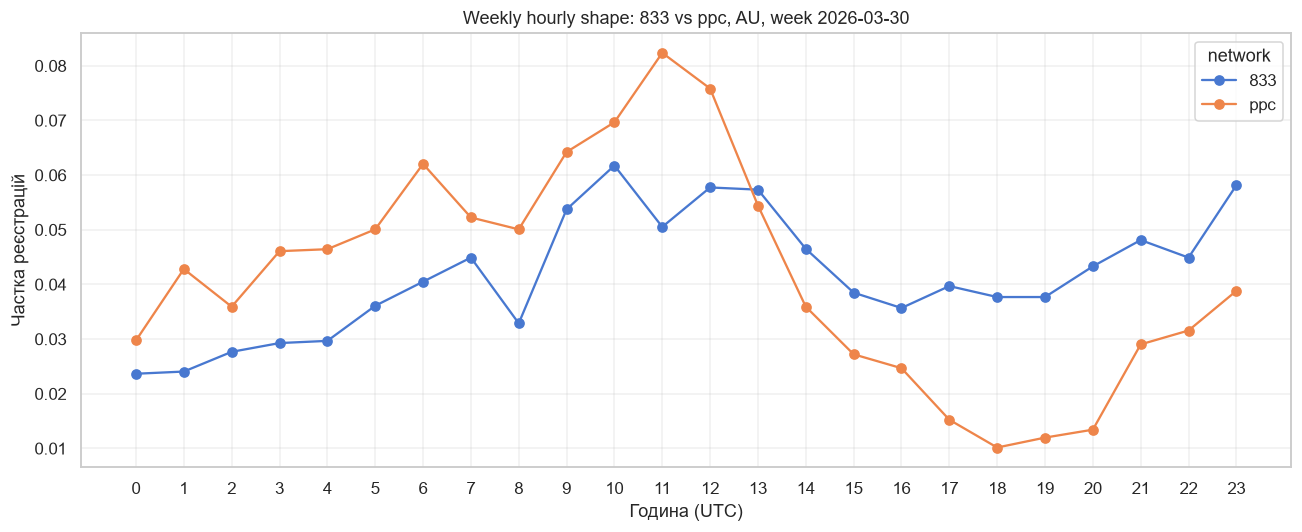

In [13]:
# --- 6.3 Візуальна перевірка найсильнішого недільного-сигналу ---
# Графік показує аномалію форми, але не клаисфікує фрод сам по собі.

top_segment = screen.dropna(subset=["ratio_to_ppc"]).nlargest(1, "ratio_to_ppc").iloc[0]
candidate_network = str(top_segment["network"])
candidate_country = str(top_segment["country"])
candidate_week = pd.Timestamp(top_segment["week"]).strftime("%Y-%m-%d")

candidate_network_sql = candidate_network.replace("'", "''")
candidate_country_sql = candidate_country.replace("'", "''")

hourly_candidate = q(f"""
    SELECT
        CAST(network AS VARCHAR) AS network,
        CAST(date_part('hour', date_created) AS INTEGER) AS utc_hour,
        COUNT(*) AS regs
    FROM reg
    WHERE network IN ('{candidate_network_sql}', 'ppc')
      AND country = '{candidate_country_sql}'
      AND date_created >= DATE '{candidate_week}'
      AND date_created < DATE '{candidate_week}' + INTERVAL 7 DAY
    GROUP BY 1, 2
""")

hourly_share = (
    hourly_candidate
    .pivot(index="utc_hour", columns="network", values="regs")
    .reindex(range(24), fill_value=0)
)
hourly_share = hourly_share.div(hourly_share.sum(axis=0), axis=1)

ax = hourly_share.plot(figsize=(12, 5), marker="o")
ax.set_title(
    f"Weekly hourly shape: {candidate_network} vs ppc, "
    f"{candidate_country}, week {candidate_week}"
)
ax.set_xlabel("Година (UTC)")
ax.set_ylabel("Частка реєстрацій")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок блоку 6 — гіпотезу про ботів не доведено, але не закрито**

- Перевірено 575 зіставних сегментів `network × country × week`.
- Стійко слабкий нічний спад є у `833/AU`, `833/US`, `523/GB` та `523/BR`.
- Окрема перевірка інтервалів 5/10/15 секунд не дала сильного доказу: найбільше відхилення має `523/PT`, але рівно 5 секунд становлять лише близько 0.3% усіх інтервалів, а 5/10/15 секунд разом — менше 0.7%.
- Великі відносні значення для інтервалів 60 секунд також виникають на дуже малих абсолютних частках.

Отже `833` і `523` залишаються кандидатами на перевірку автоматизації. Назвати їх ботовими мережами можна лише після незалежного підтвердження з поведінки або технічних слідів.


## 7. Поведінка після реєстрації

Гіпотеза: користувачі реєструються за винагороду, але не мають справжнього інтересу до продукту. Очікую одночасно:

1. більше користувачів без жодної сесії після реєстрації;
2. нижчий D7 та більше користувачів лише з однією сесією;
3. серед платників — відсутність використання credits після оплати.

Щоб не сплутати пропуски даних із фродом:

- враховую тільки сесії після `date_created`;
- виключаю місяці, де покриття `activity_log` у `ppc` нижче 10%;
- у D7 беру лише користувачів із повними сімома днями спостереження;
- D7 означає активність саме на сьомий календарний день, а не будь-коли після нього.


In [14]:
# --- 7.1 Єдиний шар активності після реєстрації ---
con.execute("""
CREATE OR REPLACE TEMP TABLE post_session_user AS
SELECT r.id_user,
       COUNT(*) AS n_sessions,
       COUNT(DISTINCT a.duration) AS distinct_durations,
       MEDIAN(a.duration) AS med_duration,
       MAX(a.date_start) AS last_session,
       MAX(CASE WHEN date_diff('day', r.date_created, a.date_start) = 7
                THEN 1 ELSE 0 END) AS retained_d7
FROM reg r
JOIN act a USING (id_user)
WHERE a.date_start >= r.date_created
GROUP BY 1
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE activity_coverage AS
SELECT date_trunc('month', r.date_created) AS registration_month,
       AVG(CASE WHEN s.id_user IS NOT NULL THEN 1.0 ELSE 0.0 END)
           AS ppc_post_session_rate
FROM reg r
LEFT JOIN post_session_user s USING (id_user)
WHERE r.network = 'ppc'
GROUP BY 1
""")

behavior_scorecard = q("""
WITH
mx AS (SELECT MAX(date_start) AS max_activity_date FROM act),
first_pay AS (
  SELECT id_user, MIN(date_created) AS first_success
  FROM pay
  WHERE status='success'
  GROUP BY 1
),
credit_after_pay AS (
  SELECT DISTINCT f.id_user
  FROM first_pay f
  JOIN cred c
    ON f.id_user=c.id_user AND c.date_created>=f.first_success
)
SELECT r.network,
       COUNT(*) AS regs,
       COUNT(*) FILTER (WHERE c.ppc_post_session_rate >= 0.10) AS valid_activity_regs,
       ROUND(AVG(CASE WHEN c.ppc_post_session_rate >= 0.10
                      THEN CASE WHEN s.id_user IS NULL THEN 1.0 ELSE 0.0 END END), 3)
           AS pct_no_session,
       ROUND(AVG(CASE WHEN c.ppc_post_session_rate >= 0.10
                           AND r.date_created <= mx.max_activity_date - INTERVAL 7 DAY
                      THEN COALESCE(s.retained_d7,0) END), 3) AS retention_d7,
       ROUND(AVG(CASE WHEN c.ppc_post_session_rate >= 0.10
                           AND s.id_user IS NOT NULL
                      THEN CASE WHEN s.n_sessions=1 THEN 1.0 ELSE 0.0 END END),3)
           AS one_session_share_active,
       ROUND(AVG(CASE WHEN c.ppc_post_session_rate >= 0.10
                           AND s.n_sessions>=2
                      THEN CASE WHEN s.distinct_durations=1 THEN 1.0 ELSE 0.0 END END),3)
           AS same_duration_share_multi,
       ROUND(MEDIAN(CASE WHEN c.ppc_post_session_rate >= 0.10
                         THEN s.n_sessions END), 1) AS med_sessions,
       ROUND(MEDIAN(CASE WHEN c.ppc_post_session_rate >= 0.10
                         THEN s.med_duration END), 1) AS med_duration_sec,
       ROUND(AVG(CASE WHEN f.id_user IS NOT NULL
                      THEN CASE WHEN cu.id_user IS NULL THEN 1.0 ELSE 0.0 END END), 3)
           AS payer_no_credit_use,
       ROUND(AVG(CASE WHEN f.id_user IS NOT NULL THEN 1.0 ELSE 0.0 END), 3) AS cr_pay
FROM reg r
LEFT JOIN post_session_user s USING (id_user)
LEFT JOIN activity_coverage c
  ON date_trunc('month', r.date_created) = c.registration_month
LEFT JOIN first_pay f USING (id_user)
LEFT JOIN credit_after_pay cu USING (id_user)
CROSS JOIN mx
GROUP BY 1
ORDER BY retention_d7
""")
display(behavior_scorecard)


,network,regs,valid_activity_regs,pct_no_session,retention_d7,one_session_share_active,same_duration_share_multi,med_sessions,med_duration_sec,payer_no_credit_use,cr_pay
0,911,267478,120509,0.236,0.015,0.632,0.007,1.000,111.000,0.078,0.004
1,851,219451,73281,0.187,0.019,0.603,0.007,1.000,91.000,0.000,0.004
2,523,790549,468223,0.239,0.022,0.595,0.007,1.000,108.500,0.119,0.007
3,833,1114202,728364,0.187,0.041,0.415,0.008,2.000,99.000,0.000,0.012
4,1052,95788,58134,0.123,0.058,0.379,0.004,2.000,116.000,0.000,0.039
5,organic,1156766,800381,0.067,0.058,0.368,0.003,2.000,107.500,0.000,0.024
6,897,153366,124809,0.157,0.058,0.380,0.003,2.000,118.500,0.000,0.036
7,303,174637,61823,0.147,0.059,0.376,0.004,2.000,129.000,0.000,0.013
8,612,111675,82535,0.152,0.066,0.358,0.004,2.000,127.000,0.000,0.029
9,1002,108535,75524,0.080,0.068,0.332,0.002,3.000,139.000,0.000,0.067


,network,comparable_segments,med_no_session_ratio,med_d7_ratio,suspicious_segment_share
0,523,51,1.372,0.225,0.588
1,911,9,1.356,0.169,0.556
2,851,31,1.299,0.248,0.484
3,833,30,1.156,0.524,0.233
4,612,22,1.122,0.739,0.045
5,1052,17,0.768,0.685,0.000
6,897,27,0.914,0.786,0.000
7,1002,26,0.523,0.796,0.000
8,303,25,0.929,0.867,0.000
9,413,21,1.006,0.900,0.000


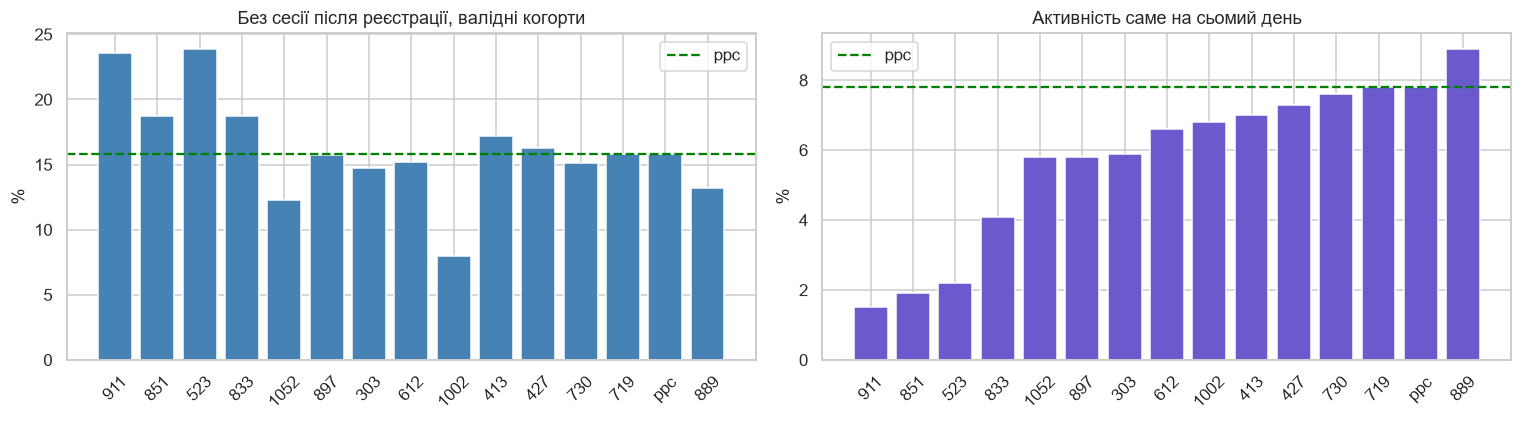

In [15]:
# --- 7.2 Порівняння в однакових country × month сегментах ---
behavior_relative = q("""
WITH mx AS (SELECT MAX(date_start) AS max_activity_date FROM act),
agg AS (
  SELECT r.network, r.country,
         CAST(date_trunc('month', r.date_created) AS DATE) AS cohort_month,
         COUNT(*) AS regs,
         AVG(CASE WHEN s.id_user IS NULL THEN 1.0 ELSE 0.0 END) AS no_session,
         AVG(CASE WHEN r.date_created <= mx.max_activity_date - INTERVAL 7 DAY
                  THEN COALESCE(s.retained_d7,0) END) AS d7
  FROM reg r
  LEFT JOIN post_session_user s USING (id_user)
  JOIN activity_coverage c
    ON date_trunc('month', r.date_created) = c.registration_month
  CROSS JOIN mx
  WHERE c.ppc_post_session_rate >= 0.10 AND r.country IS NOT NULL
  GROUP BY 1,2,3
),
paired AS (
  SELECT a.network, a.country, a.cohort_month, a.regs,
         a.no_session, a.d7, p.no_session AS ppc_no_session, p.d7 AS ppc_d7
  FROM agg a
  JOIN agg p USING (country, cohort_month)
  WHERE p.network='ppc' AND a.network NOT IN ('ppc','organic')
    AND a.regs >= 500 AND p.regs >= 500
)
SELECT network, COUNT(*) AS comparable_segments,
       ROUND(MEDIAN(no_session / NULLIF(ppc_no_session,0)), 3) AS med_no_session_ratio,
       ROUND(MEDIAN(d7 / NULLIF(ppc_d7,0)), 3) AS med_d7_ratio,
       ROUND(AVG(CASE WHEN no_session > ppc_no_session*1.30
                           AND d7 < ppc_d7*0.60 THEN 1.0 ELSE 0.0 END), 3)
           AS suspicious_segment_share
FROM paired
GROUP BY 1
ORDER BY suspicious_segment_share DESC, med_d7_ratio
""")
display(behavior_relative)

base_b = behavior_scorecard.loc[behavior_scorecard.network=='ppc'].iloc[0]
d = behavior_scorecard[~behavior_scorecard.network.isin(['organic'])].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(d.network.astype(str), d.pct_no_session*100, color='steelblue')
axes[0].axhline(base_b.pct_no_session*100, color='green', ls='--', label='ppc')
axes[0].set_title('Без сесії після реєстрації, валідні когорти')
axes[0].set_ylabel('%'); axes[0].tick_params(axis='x', rotation=45); axes[0].legend()
axes[1].bar(d.network.astype(str), d.retention_d7*100, color='slateblue')
axes[1].axhline(base_b.retention_d7*100, color='green', ls='--', label='ppc')
axes[1].set_title('Активність саме на сьомий день')
axes[1].set_ylabel('%'); axes[1].tick_params(axis='x', rotation=45); axes[1].legend()
plt.tight_layout(); plt.show()


### 7.3 Чи погіршилась якість останнім часом

Загальний підсумок може приховати ситуацію, коли партнер довго працював нормально, а потім почав домішувати слабкий або фродовий трафік. Тому порівнюю останні 30 днів із повністю доступним D7-вікном із попередніми 30 днями.


In [16]:
recent_quality = q("""
WITH mx AS (SELECT MAX(date_start) AS max_activity_date FROM act),
base AS (
  SELECT r.network,
         CASE
           WHEN r.date_created > mx.max_activity_date - INTERVAL 37 DAY
             THEN 'останні 30 днів з повним D7-вікном'
           ELSE 'попередні 30 днів'
         END AS period,
         CASE WHEN s.id_user IS NULL THEN 1.0 ELSE 0.0 END AS no_session,
         COALESCE(s.retained_d7,0) AS d7
  FROM reg r
  LEFT JOIN post_session_user s USING(id_user)
  JOIN activity_coverage c
    ON date_trunc('month',r.date_created)=c.registration_month
  CROSS JOIN mx
  WHERE c.ppc_post_session_rate>=0.10
    AND r.date_created>mx.max_activity_date-INTERVAL 67 DAY
    AND r.date_created<=mx.max_activity_date-INTERVAL 7 DAY
),
agg AS (
  SELECT network,period,COUNT(*) AS regs,
         AVG(no_session) AS no_session,
         AVG(d7) AS d7
  FROM base
  GROUP BY 1,2
)
SELECT network,
       MAX(regs) FILTER (WHERE period='останні 30 днів з повним D7-вікном') AS recent_regs,
       ROUND(MAX(d7) FILTER (WHERE period='останні 30 днів з повним D7-вікном'),3) AS recent_d7,
       ROUND(MAX(d7) FILTER (WHERE period='попередні 30 днів'),3) AS previous_d7,
       ROUND(
         MAX(d7) FILTER (WHERE period='останні 30 днів з повним D7-вікном')
         / NULLIF(MAX(d7) FILTER (WHERE period='попередні 30 днів'),0),3
       ) AS d7_change_ratio,
       ROUND(MAX(no_session) FILTER (WHERE period='останні 30 днів з повним D7-вікном'),3)
         AS recent_no_session,
       ROUND(MAX(no_session) FILTER (WHERE period='попередні 30 днів'),3)
         AS previous_no_session
FROM agg
GROUP BY 1
ORDER BY d7_change_ratio
""")
display(recent_quality)


,network,recent_regs,recent_d7,previous_d7,d7_change_ratio,recent_no_session,previous_no_session
0,851,3760,0.022,0.028,0.765,0.168,0.162
1,organic,165711,0.051,0.059,0.851,0.062,0.070
2,413,56517,0.064,0.073,0.872,0.183,0.165
3,523,107786,0.018,0.020,0.900,0.239,0.229
4,911,20336,0.011,0.012,0.912,0.249,0.268
5,897,31301,0.061,0.066,0.921,0.154,0.155
6,889,14085,0.086,0.093,0.924,0.143,0.130
7,303,12364,0.059,0.063,0.940,0.148,0.163
8,719,13010,0.081,0.086,0.941,0.149,0.151
9,730,20592,0.058,0.062,0.944,0.174,0.170


**Висновок блоку 7**

- `523` і `911` мають значно нижчу активність на сьомий день, більшу частку
  користувачів без сесій та майже вдвічі більшу частку активних користувачів
  лише з однією сесією, ніж `ppc`.
- Частина платників `523/911` не використовує credits навіть після успішної
  оплати. Це окреме підтвердження того, що реєстрація або оплата могли бути
  зроблені заради винагороди, а не заради продукту.
- Однакова тривалість кількох сесій трапляється рідко і майже не відрізняється
  від `ppc`. Сценарій примітивного бота з повністю однаковою поведінкою не
  підтвердився.
- `851` має слабку активність, але без незалежного фінансового чи технічного
  сигналу цього недостатньо для висновку про фрод.
- Гіпотеза щодо `303` не підтвердилась: після виправлення покриття
  `activity_log` поведінка мережі значно ближча до нормальної.
- В останні 30 днів із повним D7-вікном найбільше зниження D7 має `851` — з 2.8% до 2.2%.
  У `523` показник знизився з 2.0% до 1.8%, у `911` — з 1.2% до 1.1%.
  Це продовження вже наявної слабкої якості, а не різкий новий сплеск фроду.

## 8. Технічні сліди

Перевіряю доступні технічні ознаки: `user_agent`, `device_os`, повторні реєстрації одного `id_metauser`, структуру email та час від візиту до реєстрації. Якщо поле відсутнє або анонімізоване, не використовую це як доказ проти конкретного партнера.


In [17]:
# --- 8.1 Якість і концентрація технічних полів ---
tech_quality = q("""
WITH base AS (
  SELECT network,user_agent,device_os,country,
         lower(split_part(email,'@',1)) AS email_local
  FROM reg
),
os_counts AS (
  SELECT network,device_os,COUNT(*) AS n
  FROM base
  GROUP BY 1,2
),
os_stats AS (
  SELECT network,MAX(n) AS top_os_n
  FROM os_counts
  GROUP BY 1
)
SELECT b.network,COUNT(*) AS regs,
       ROUND(AVG(CASE WHEN b.user_agent IS NULL THEN 1.0 ELSE 0.0 END),3)
         AS ua_null,
       COUNT(DISTINCT b.user_agent) AS distinct_ua,
       COUNT(DISTINCT b.device_os) AS distinct_os,
       ROUND(o.top_os_n/COUNT(*),3) AS top_os_share,
       COUNT(DISTINCT b.country) AS countries,
       ROUND(AVG(CASE WHEN regexp_matches(b.email_local,'^[0-9a-f]{8}$')
                      THEN 1.0 ELSE 0.0 END),3) AS anonymized_email_share
FROM base b
JOIN os_stats o USING(network)
GROUP BY b.network,o.top_os_n
ORDER BY ua_null DESC
""")
display(tech_quality)

metauser_reuse = q("""
WITH m AS (
  SELECT network, id_metauser, COUNT(*) AS regs
  FROM reg GROUP BY 1,2
)
SELECT network, COUNT(*) AS metausers,
       ROUND(AVG(CASE WHEN regs>1 THEN 1.0 ELSE 0.0 END),3) AS repeated_metauser_share,
       quantile_cont(regs,0.99) AS p99_regs_per_metauser,
       MAX(regs) AS max_regs_per_metauser
FROM m GROUP BY 1 ORDER BY repeated_metauser_share DESC
""")
display(metauser_reuse)

visit_lag = q("""
SELECT network,
       ROUND(MEDIAN(epoch(date_created)-epoch(date_visit)),1) AS med_visit_to_reg_sec,
       ROUND(quantile_cont(epoch(date_created)-epoch(date_visit),0.10),1) AS p10_sec,
       ROUND(quantile_cont(epoch(date_created)-epoch(date_visit),0.90),1) AS p90_sec,
       ROUND(AVG(CASE WHEN date_created=date_visit THEN 1.0 ELSE 0.0 END),3) AS exact_zero_share
FROM reg GROUP BY 1 ORDER BY med_visit_to_reg_sec
""")
display(visit_lag)


,network,regs,ua_null,distinct_ua,distinct_os,top_os_share,countries,anonymized_email_share
0,911,267478,1.000,0,5,0.884,91,1.000
1,1052,95788,1.000,0,5,0.400,143,1.000
2,897,153366,1.000,0,5,0.544,168,1.000
3,1002,108535,1.000,0,5,0.440,175,1.000
4,523,790549,1.000,0,5,0.774,201,1.000
5,833,1114202,1.000,0,5,0.524,124,1.000
6,303,174637,1.000,0,5,0.808,133,1.000
7,889,62118,1.000,0,5,0.822,36,1.000
8,730,137252,1.000,0,5,0.760,178,1.000
9,427,232251,1.000,0,5,0.534,134,1.000


,network,metausers,repeated_metauser_share,p99_regs_per_metauser,max_regs_per_metauser
0,organic,805503,0.165,6.000,15401
1,833,920470,0.130,4.000,35
2,413,157939,0.123,3.000,39
3,427,199937,0.114,3.000,68
4,ppc,2696531,0.086,4.000,327
5,897,139047,0.080,3.000,50
6,1002,98951,0.060,3.000,89
7,1052,89500,0.056,2.000,18
8,719,116487,0.047,2.000,30
9,612,106562,0.036,2.000,64


,network,med_visit_to_reg_sec,p10_sec,p90_sec,exact_zero_share
0,organic,45.800,5.800,291.800,0.054
1,523,112.000,27.700,242.700,0.002
2,1002,116.500,57.800,249.600,0.005
3,833,127.700,69.100,248.000,0.003
4,851,127.900,70.200,277.700,0.004
5,911,146.700,84.900,281.700,0.002
6,612,150.300,80.600,306.600,0.008
7,427,158.000,96.700,309.900,0.001
8,719,163.200,96.000,324.300,0.004
9,1052,165.600,80.100,373.400,0.002


**Висновок блоку 8**

- Для всіх партнерських мереж `user_agent` відсутній, тоді як у `ppc` поле майже повне. Перевірити повторюваний user-agent на цих даних неможливо.
- Локальна частина всіх email замінена на восьмизначний код, тому шаблони адрес також непридатні для пошуку ботів.
- У кількох мережах один `device_os` займає велику частку трафіку, але без порівняння в однакових країнах це може бути лише різницею аудиторії.
- Масові повторні реєстрації одного `id_metauser` у `523/911/851` не підтвердились.
- Час від візиту до реєстрації відрізняється між каналами, але не дає надійного порогу без даних про рекламні кліки та правила атрибуції.

Цей блок не підтвердив окремий технічний механізм фроду. Далі використовую `id_metauser` інакше: перевіряю, чи не отримують партнери оплату за користувачів, яких продукт уже залучив раніше.


## 9. Повторна атрибуція вже відомих користувачів

Гіпотеза: партнер може отримувати винагороду не за нових користувачів, а за повторні реєстрації людей, яких раніше вже привели `ppc` або `organic`.

Перевіряю:

1. частку реєстрацій, де `id_metauser` раніше вже був у чистому каналі;
2. частку витрат на таких користувачів;
3. чи конвертуються вони краще за справді нових користувачів;
4. як швидко після першої реєстрації відбувається повторна.

Високі значення ще не доводять фрод: це може бути дозволений ретаргетинг. Тому фінальний висновок залежить від правил attribution window.


,network,regs,prior_clean_share,prior_clean_share_costed,spend_share_prior_clean,cr_prior_clean,cr_other,cr_lift_prior_clean,prior_clean_within7d,median_days
0,719,123232,0.133,0.157,0.166,0.056,0.031,1.800,0.033,30.000
1,413,184394,0.075,0.082,0.082,0.071,0.046,1.540,0.010,65.000
2,427,232251,0.067,0.073,0.072,0.069,0.048,1.440,0.009,57.000
3,889,62118,0.057,0.065,0.067,0.036,0.022,1.630,0.011,37.000
4,612,111675,0.084,0.056,0.059,0.039,0.028,1.390,0.028,17.000
5,730,137252,0.044,0.048,0.039,0.048,0.041,1.170,0.007,45.000
6,1052,95788,0.049,0.019,0.031,0.060,0.037,1.590,0.012,35.000
7,1002,108535,0.049,0.021,0.027,0.084,0.066,1.270,0.013,28.000
8,303,174637,0.036,0.026,0.020,0.017,0.013,1.320,0.005,42.000
9,833,1114202,0.034,0.021,0.019,0.022,0.011,1.960,0.007,36.000


,first_network,regs,costed_share,median_days
0,ppc,13845,0.739,29.000
1,organic,2533,0.745,34.000


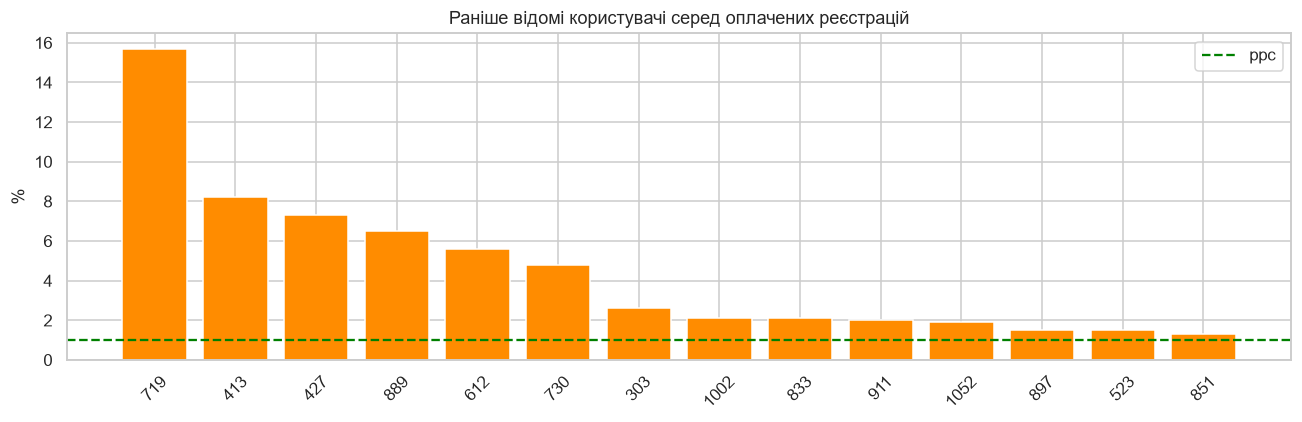

In [18]:
# --- 9.1 Історія id_metauser між мережами ---
con.execute("""
CREATE OR REPLACE TEMP TABLE attribution_registration AS
WITH first_touch AS (
  SELECT id_metauser,
         MIN(date_created) AS first_date,
         arg_min(CAST(network AS VARCHAR),date_created) AS first_network
  FROM reg
  WHERE id_metauser IS NOT NULL
  GROUP BY 1
),
payers AS (
  SELECT id_user,MAX(status='success') AS paid
  FROM pay
  GROUP BY 1
)
SELECT CAST(r.network AS VARCHAR) AS network,
       r.id_user,r.id_metauser,r.country,r.date_created,r.cost,
       COALESCE(p.paid,FALSE) AS paid,
       f.first_date,f.first_network,
       COALESCE(
         r.date_created>f.first_date
         AND f.first_network IN ('ppc','organic')
         AND f.first_network<>CAST(r.network AS VARCHAR),
         FALSE
       ) AS prior_clean,
       date_diff('day',f.first_date,r.date_created) AS days_since_first
FROM reg r
LEFT JOIN first_touch f USING(id_metauser)
LEFT JOIN payers p USING(id_user)
""")

attribution_scorecard = q("""
SELECT network,COUNT(*) AS regs,
       ROUND(AVG(prior_clean::INTEGER),3) AS prior_clean_share,
       ROUND(AVG(prior_clean::INTEGER) FILTER (WHERE cost IS NOT NULL),3)
         AS prior_clean_share_costed,
       ROUND(SUM(cost) FILTER (WHERE prior_clean)/NULLIF(SUM(cost),0),3)
         AS spend_share_prior_clean,
       ROUND(AVG(paid::INTEGER) FILTER (WHERE prior_clean),3) AS cr_prior_clean,
       ROUND(AVG(paid::INTEGER) FILTER (WHERE NOT prior_clean),3) AS cr_other,
       ROUND(
         AVG(paid::INTEGER) FILTER (WHERE prior_clean)
         / NULLIF(AVG(paid::INTEGER) FILTER (WHERE NOT prior_clean),0),2
       ) AS cr_lift_prior_clean,
       ROUND(AVG(CASE WHEN prior_clean AND days_since_first<=7
                      THEN 1.0 ELSE 0.0 END),3) AS prior_clean_within7d,
       MEDIAN(days_since_first) FILTER (WHERE prior_clean) AS median_days
FROM attribution_registration
GROUP BY 1
ORDER BY spend_share_prior_clean DESC NULLS LAST
""")
display(attribution_scorecard)

display(q("""
SELECT first_network,COUNT(*) AS regs,
       ROUND(AVG(CASE WHEN cost IS NOT NULL THEN 1.0 ELSE 0.0 END),3)
         AS costed_share,
       MEDIAN(days_since_first) AS median_days
FROM attribution_registration
WHERE network='719' AND prior_clean
GROUP BY 1
ORDER BY regs DESC
"""))

d = attribution_scorecard[
    ~attribution_scorecard.network.isin(['ppc','organic'])
].sort_values('prior_clean_share_costed',ascending=False)
fig,ax=plt.subplots(figsize=(12,4))
ax.bar(d.network,d.prior_clean_share_costed*100,color='darkorange')
ax.axhline(
    attribution_scorecard.loc[
        attribution_scorecard.network=='ppc','prior_clean_share_costed'
    ].iloc[0]*100,
    color='green',ls='--',label='ppc'
)
ax.set_title('Раніше відомі користувачі серед оплачених реєстрацій')
ax.set_ylabel('%'); ax.tick_params(axis='x',rotation=45); ax.legend()
plt.tight_layout(); plt.show()


**Висновок блоку 9**

- `719` суттєво виділяється: 13.3% усіх реєстрацій уже мали перше касання
  через `ppc/organic`; серед реєстрацій із ненульовою виплатою таких 15.7%,
  і на них припадає 16.6% витрат.
- Такі користувачі конвертуються в оплату приблизно у 1.8 раза краще за
  інших користувачів `719`. Це природно для вже знайомої з продуктом
  аудиторії й водночас робить повторну атрибуцію вигідною для партнера.
- `413/427` також мають підвищені значення, але там більше взаємних переходів
  між мережами та довший часовий проміжок. Це може бути повторне залучення
  або життєвий цикл кампаній, тому доказів фроду недостатньо.
- Для `612` повторні користувачі трапляються частіше, ніж у `ppc`, але на них
  припадає лише невелика частка витрат. Головними проблемами цієї мережі
  залишаються кардинг і зловживання CPS.

`719` переводжу в статус **candidate**: можливе перехоплення або повторний
продаж уже залучених користувачів. До перевірки вікна атрибуції це не
доведений фрод. Дія — не оплачувати повторні `id_metauser`, якщо така
атрибуція не передбачена договором.

## 10. Платежі та кардинг

Гіпотеза: партнер приводить користувачів, які оплачують продукт вкраденими картками. Очікую кілька незалежних проявів:

- аномальну частку успішних оплат із chargeback;
- велику частку поверненої суми;
- концентрацію chargeback на рівні користувача;
- велику кількість платіжних спроб або повторні спроб за короткий час;
- фінансовий збиток після 60 днів, коли платежі вже встигли отримати chargeback.


In [19]:
# --- 10.1 Chargeback і швидкість платіжних спроб ---
chargeback_dq = q("""
SELECT COUNT(*) FILTER (WHERE chargeback_date IS NOT NULL) AS chargeback_rows,
       COUNT(*) FILTER (WHERE chargeback_date < date_created) AS cb_before_payment,
       ROUND(AVG(CASE WHEN chargeback_date < date_created THEN 1.0 ELSE 0.0 END)
             FILTER (WHERE chargeback_date IS NOT NULL),3) AS negative_lag_share,
       MEDIAN(date_diff('day',date_created,chargeback_date))
             FILTER (WHERE chargeback_date IS NOT NULL) AS median_lag_days
FROM pay
""")
display(chargeback_dq)

pay_scorecard = q("""
WITH mx AS (SELECT MAX(date_created) AS max_payment_date FROM pay),
j0 AS (
  SELECT r.network,p.*
  FROM pay p JOIN reg r USING(id_user)
),
j AS (
  SELECT *,
         date_diff(
           'second',
           LAG(date_created) OVER (
             PARTITION BY id_user ORDER BY date_created
           ),
           date_created
         ) AS gap_seconds
  FROM j0
),
pu AS (
  SELECT network,id_user,
         COUNT(*) AS attempts,
         COUNT(*) FILTER (WHERE status='success') AS success_n,
         COUNT(*) FILTER (
           WHERE status='success' AND chargeback_date IS NOT NULL
         ) AS cb_n,
         MAX(CASE WHEN gap_seconds BETWEEN 0 AND 60 THEN 1 ELSE 0 END)
           AS has_gap_le_60s,
         MAX(CASE WHEN gap_seconds BETWEEN 0 AND 600 THEN 1 ELSE 0 END)
           AS has_gap_le_10m
  FROM j
  GROUP BY 1,2
),
payment_agg AS (
  SELECT j.network,
         COUNT(DISTINCT j.id_user) AS payers_any_attempt,
         ROUND(AVG(CASE WHEN j.status='fail' THEN 1.0 ELSE 0.0 END),3) AS fail_rate,
         ROUND(COUNT(*) FILTER (
                 WHERE j.status='success' AND j.chargeback_date IS NOT NULL
               ) / NULLIF(COUNT(*) FILTER (WHERE j.status='success'),0),4)
           AS cb_rate,
         ROUND(SUM(j.amount) FILTER (
                 WHERE j.status='success' AND j.chargeback_date IS NOT NULL
               ) / NULLIF(SUM(j.amount) FILTER (WHERE j.status='success'),0),4)
           AS cb_by_amount,
         ROUND(COUNT(*) FILTER (
                 WHERE j.status='success'
                   AND j.chargeback_date IS NOT NULL
                   AND j.date_created<=mx.max_payment_date-INTERVAL 60 DAY
               ) / NULLIF(COUNT(*) FILTER (
                 WHERE j.status='success'
                   AND j.date_created<=mx.max_payment_date-INTERVAL 60 DAY
               ),0),4) AS cb_count_rate_payment_60dplus,
         ROUND(SUM(j.amount) FILTER (
                 WHERE j.status='success'
                   AND j.chargeback_date IS NOT NULL
                   AND j.date_created<=mx.max_payment_date-INTERVAL 60 DAY
               ) / NULLIF(SUM(j.amount) FILTER (
                 WHERE j.status='success'
                   AND j.date_created<=mx.max_payment_date-INTERVAL 60 DAY
               ),0),4) AS cb_amount_rate_payment_60dplus,
         ROUND(SUM(j.amount) FILTER (
                 WHERE j.status='success' AND j.chargeback_date IS NOT NULL
               ),0) AS cb_lost_usd
  FROM j
  CROSS JOIN mx
  GROUP BY 1
),
user_agg AS (
  SELECT network,
         ROUND(AVG(attempts),1) AS attempts_per_user,
         ROUND(quantile_cont(attempts,0.99),1) AS p99_attempts,
         ROUND(AVG(has_gap_le_60s),4) AS users_with_gap_le_60s,
         ROUND(AVG(has_gap_le_10m),4) AS users_with_gap_le_10m,
         ROUND(AVG(CASE WHEN success_n>0 AND cb_n=success_n
                        THEN 1.0 ELSE 0.0 END),4) AS users_all_success_cb
  FROM pu
  GROUP BY 1
)
SELECT p.*,u.attempts_per_user,u.p99_attempts,
       u.users_with_gap_le_60s,u.users_with_gap_le_10m,
       u.users_all_success_cb
FROM payment_agg p
JOIN user_agg u USING(network)
ORDER BY p.cb_amount_rate_payment_60dplus DESC
""")
display(pay_scorecard)


,chargeback_rows,cb_before_payment,negative_lag_share,median_lag_days
0,7925,2434,0.307,24.000


,network,payers_any_attempt,fail_rate,cb_rate,cb_by_amount,cb_count_rate_payment_60dplus,cb_amount_rate_payment_60dplus,cb_lost_usd,attempts_per_user,p99_attempts,users_with_gap_le_60s,users_with_gap_le_10m,users_all_success_cb
0,1052,5012,0.363,0.035,0.145,0.054,0.212,"1,505,315.000",10.300,155.700,0.316,0.502,0.001
1,612,5413,0.390,0.150,0.096,0.147,0.121,"104,500.000",2.100,21.000,0.037,0.062,0.120
2,911,3377,0.678,0.006,0.010,0.006,0.008,"11,860.000",2.800,26.200,0.107,0.288,0.002
3,851,2709,0.684,0.003,0.005,0.004,0.007,"2,265.000",3.800,27.900,0.184,0.343,0.001
4,427,13655,0.309,0.005,0.005,0.004,0.005,"77,010.000",7.300,90.000,0.286,0.448,0.002
5,303,4905,0.502,0.006,0.004,0.006,0.005,"4,205.000",4.000,51.000,0.104,0.254,0.001
6,organic,46005,0.419,0.004,0.004,0.005,0.005,"214,855.000",9.600,149.000,0.268,0.461,0.002
7,897,6881,0.291,0.005,0.004,0.004,0.004,"28,860.000",9.100,157.200,0.267,0.431,0.002
8,ppc,133177,0.450,0.004,0.004,0.004,0.004,"459,150.000",8.800,126.200,0.256,0.446,0.001
9,523,11421,0.539,0.004,0.004,0.004,0.004,"15,265.000",3.800,43.000,0.202,0.371,0.001


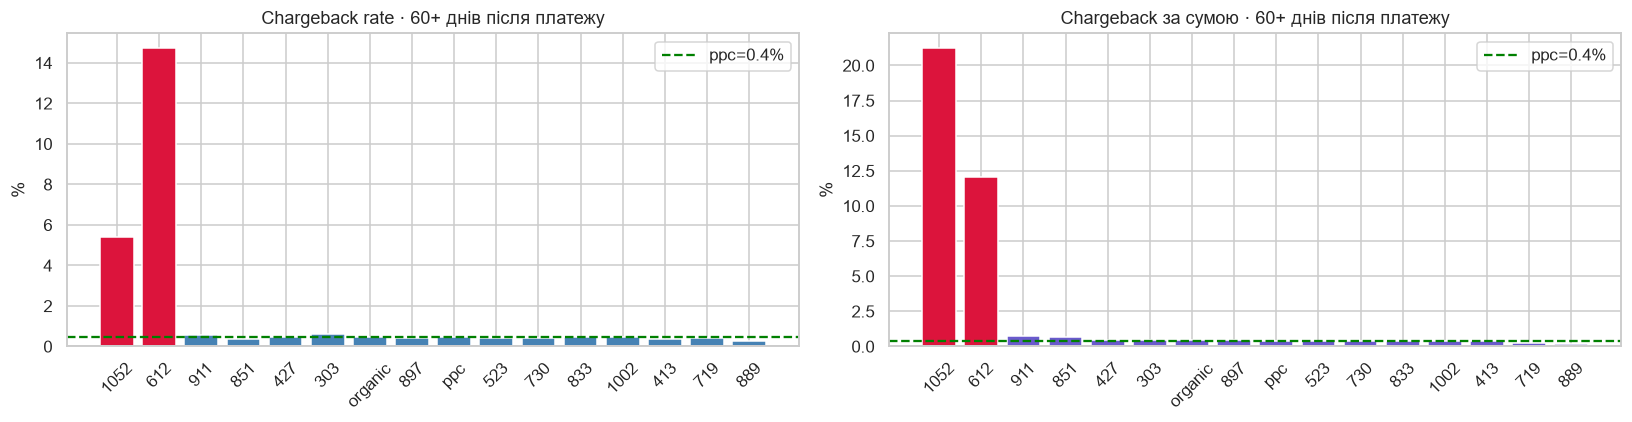

In [20]:
# --- 10.2 Візуалізація carding: частота та гроші ---
base_cb = pay_scorecard.loc[pay_scorecard.network=='ppc','cb_count_rate_payment_60dplus'].iloc[0]
base_amt = pay_scorecard.loc[pay_scorecard.network=='ppc','cb_amount_rate_payment_60dplus'].iloc[0]
d = pay_scorecard.sort_values('cb_amount_rate_payment_60dplus', ascending=False)
fig, axes = plt.subplots(1,2,figsize=(15,4))
axes[0].bar(d.network.astype(str), d.cb_count_rate_payment_60dplus*100,
            color=['crimson' if x>base_cb*3 else 'steelblue' for x in d.cb_count_rate_payment_60dplus])
axes[0].axhline(base_cb*100,color='green',ls='--',label=f'ppc={base_cb:.1%}')
axes[0].set_title('Chargeback rate · 60+ днів після платежу'); axes[0].set_ylabel('%')
axes[0].tick_params(axis='x',rotation=45); axes[0].legend()
axes[1].bar(d.network.astype(str), d.cb_amount_rate_payment_60dplus*100,
            color=['crimson' if x>base_amt*3 else 'slateblue' for x in d.cb_amount_rate_payment_60dplus])
axes[1].axhline(base_amt*100,color='green',ls='--',label=f'ppc={base_amt:.1%}')
axes[1].set_title('Chargeback за сумою · 60+ днів після платежу'); axes[1].set_ylabel('%')
axes[1].tick_params(axis='x',rotation=45); axes[1].legend()
plt.tight_layout(); plt.show()


**Висновок щодо кардингу**

- `1052` має найбільшу частку поверненої суми та близько **$1.5M** втрат. Аномалія зберігається серед платежів, яким уже виповнилося 60 днів.
- У `1052` також частіше трапляються повторні платіжні спроби протягом хвилини, але цей показник сам по собі не унікальний. Він лише підсилює висновок разом із chargeback.
- `612` має екстремальну частоту chargeback і від'ємну економіку.
- `fail_rate` у цих мереж не перевищує `ppc`, тому не використовую його як самостійний доказ.
- Через некоректні значення `chargeback_date` не будую точний поріг на основі фактичного lag. Натомість використовую наявність chargeback і окремо обмежую аналіз платежами, від яких минуло 60+ днів.

Дія: `612` — припинити співпрацю та переглянути невиплачені конверсії; `1052` — затримка виплат на 60 днів, резерв під повернення, платіжні обмеження та перегляд ставки.


## 11. Перевірка підміни країни

Порівнюю країну реєстрації з країною платежу після приведення обох полів до одного формату. Окремо перевіряю сценарій, коли користувач зареєстрований у дешевшій країні, але платить із Tier-1.


In [21]:
import pycountry
iso_map = pd.DataFrame([(c.alpha_3,c.alpha_2) for c in pycountry.countries],
                       columns=['iso3','iso2']).astype({'iso3': 'object', 'iso2': 'object'})
con.register('iso_map',iso_map)

geo_network = q("""
WITH j AS (
 SELECT r.network, r.country AS reg_c, im.iso2 AS pay_c
 FROM pay p JOIN reg r USING(id_user)
 LEFT JOIN iso_map im ON upper(p.country_payment)=im.iso3
 WHERE p.status='success' AND im.iso2 IS NOT NULL
),
t1 AS (SELECT unnest(['US','GB','DE','CA','AU','FR','NL','SE','NO','CH','DK']) AS c)
SELECT network,
 ROUND(AVG(CASE WHEN pay_c<>reg_c THEN 1.0 ELSE 0.0 END),3) AS geo_mismatch,
 ROUND(AVG(CASE WHEN reg_c NOT IN (SELECT c FROM t1)
                     AND pay_c IN (SELECT c FROM t1) THEN 1.0 ELSE 0.0 END),3)
      AS cheap_reg_rich_pay
FROM j GROUP BY 1 ORDER BY cheap_reg_rich_pay DESC
""")
display(geo_network)

geo_pairs = q("""
WITH j AS (
 SELECT r.country AS reg_c, im.iso2 AS pay_c
 FROM pay p JOIN reg r USING(id_user)
 LEFT JOIN iso_map im ON upper(p.country_payment)=im.iso3
 WHERE p.status='success' AND im.iso2 IS NOT NULL AND im.iso2<>r.country
)
SELECT reg_c||' → '||pay_c AS pair, COUNT(*) AS n
FROM j GROUP BY 1 ORDER BY n DESC LIMIT 10
""")
display(geo_pairs)


,network,geo_mismatch,cheap_reg_rich_pay
0,851,0.058,0.033
1,ppc,0.044,0.026
2,303,0.064,0.025
3,897,0.037,0.024
4,730,0.029,0.021
5,organic,0.045,0.020
6,1002,0.037,0.018
7,413,0.014,0.008
8,427,0.012,0.008
9,719,0.016,0.007


,pair,n
0,AR → US,2945
1,PH → US,1948
2,CA → US,1484
3,MX → US,979
4,SE → FI,880
5,PR → US,846
6,ES → GB,725
7,MP → US,724
8,BR → US,640
9,MX → CA,591


**Висновок блоку 11**

Систематична підміна дешевої країни під Tier-1 не підтвердилась. Рівень таких невідповідностей близький до `ppc`, а найпоширеніші пари мають звичайні пояснення: міграція, території США або картка іншої країни. Гіпотезу залишаю в роботі як перевірену та спростовану.


## 12. Ризики CPS: одна оплата та слабка економіка користувача

У CPS високий відсоток оплат може виглядати добре, навіть якщо партнер створює мінімальну оплату тільки заради винагороди. Перевіряю:

- одну успішну оплату;
- низький перший чек;
- ситуації, де виплата партнеру перевищує чистий дохід від користувача;
- використання credits після покупки;
- загальний ROAS партнера, щоб не сплутати фрод із ризиковою, але прибутковою угодою.


,network,payers,one_payment_share_cohort_60dplus,low_first_payment_share,med_net_revenue,med_partner_cost,share_cost_gt_net,payer_no_credit_use
0,612,3247,0.907,0.636,65.000,549.800,0.960,0.000
1,1002,7262,0.475,0.545,150.000,550.600,0.750,0.000
2,889,1399,0.530,0.777,110.000,258.300,0.697,0.000
3,1052,3693,0.471,0.314,165.000,444.000,0.586,0.000
4,ppc,81055,0.476,0.667,150.000,8.400,0.003,0.000


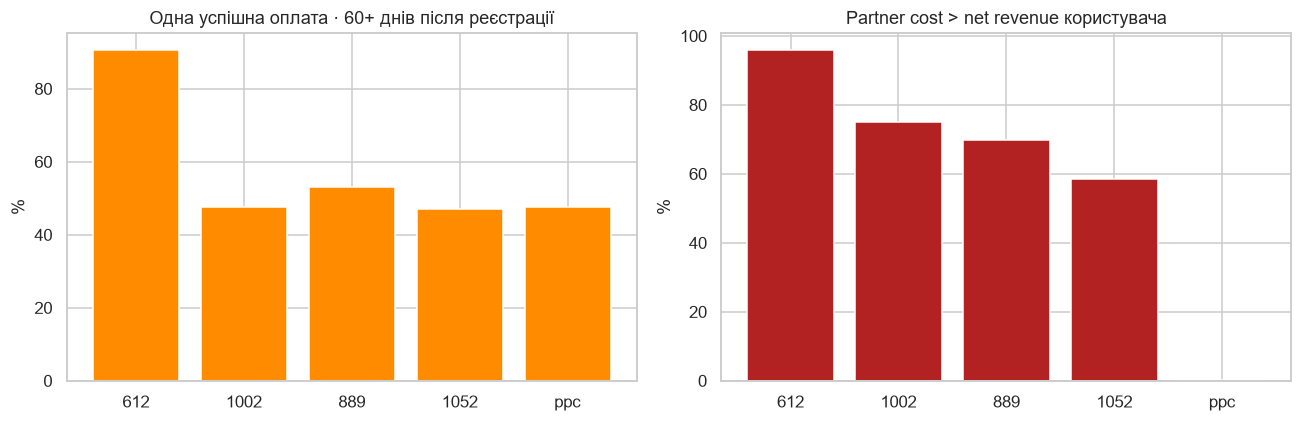

In [22]:
cps_scorecard = q("""
WITH mx AS (SELECT MAX(date_created) AS max_payment_date FROM pay),
pu AS (
 SELECT id_user,
        COUNT(*) FILTER (WHERE status='success') AS success_payments,
        SUM(amount) FILTER (WHERE status='success') AS gross,
        SUM(amount) FILTER (WHERE status='success' AND chargeback_date IS NOT NULL) AS cb,
        arg_min(amount,date_created) FILTER (WHERE status='success') AS first_amount
 FROM pay GROUP BY 1
),
cu AS (SELECT DISTINCT id_user FROM cred)
SELECT r.network,
 COUNT(*) FILTER (WHERE p.success_payments>0) AS payers,
 ROUND(AVG(CASE WHEN p.success_payments=1 THEN 1.0 ELSE 0.0 END)
       FILTER (WHERE p.success_payments>0 AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY),3)
      AS one_payment_share_cohort_60dplus,
 ROUND(AVG(CASE WHEN p.first_amount<=65 THEN 1.0 ELSE 0.0 END)
       FILTER (WHERE p.success_payments>0 AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY),3)
      AS low_first_payment_share,
 ROUND(MEDIAN(p.gross-coalesce(p.cb,0))
       FILTER (WHERE p.success_payments>0 AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY),1)
      AS med_net_revenue,
 ROUND(MEDIAN(r.cost)
       FILTER (WHERE p.success_payments>0 AND r.cost IS NOT NULL
                     AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY),1)
      AS med_partner_cost,
 ROUND(AVG(CASE WHEN r.cost>p.gross-coalesce(p.cb,0) THEN 1.0 ELSE 0.0 END)
       FILTER (WHERE p.success_payments>0 AND r.cost IS NOT NULL
                     AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY),3)
      AS share_cost_gt_net,
 ROUND(AVG(CASE WHEN cu.id_user IS NULL THEN 1.0 ELSE 0.0 END)
       FILTER (WHERE p.success_payments>0),3) AS payer_no_credit_use
FROM reg r
JOIN pu p USING(id_user)
LEFT JOIN cu USING(id_user)
CROSS JOIN mx
WHERE r.network IN ('612','889','1002','1052','ppc')
GROUP BY 1 ORDER BY share_cost_gt_net DESC
""")
display(cps_scorecard)

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(cps_scorecard.network.astype(str),cps_scorecard.one_payment_share_cohort_60dplus*100,color='darkorange')
axes[0].set_title('Одна успішна оплата · 60+ днів після реєстрації'); axes[0].set_ylabel('%')
axes[1].bar(cps_scorecard.network.astype(str),cps_scorecard.share_cost_gt_net*100,color='firebrick')
axes[1].set_title('Partner cost > net revenue користувача'); axes[1].set_ylabel('%')
plt.tight_layout(); plt.show()


**Висновок блоку 12**

- `612`: серед платників, від реєстрації яких минуло 60+ днів, близько 91% мають лише одну успішну оплату, а виплата партнеру майже завжди перевищує дохід від користувача. Разом із chargeback та ROAS нижче 1 це підтверджує зловживання.
- `1002` та `889`: ризик переплати на рівні окремого користувача високий, але користувачі витрачають credits, а партнери залишаються прибутковими. Масовий churn-and-burn не підтвердився.
- `1052` має високу вартість користувача, але його головний доведений механізм — кардинг.

Для `1002/889` потрібен контроль виплат за D60/LTV, але підстав називати їх підтвердженим фродом немає.


## 13. Економіка та ROAS

Порівнюю загальний ROAS і ROAS когорт, від реєстрації яких минуло 60+ днів. Другий показник не означає, що від кожного платежу в когорті також минуло 60 днів: це окремо контролюється в chargeback-метриках за датою платежу.

ROAS визначає бізнес-дію, але не замінює перевірку фроду.


,network,spend,net_revenue,roas,profit,roas_cohort_60dplus
0,612,"1,168,206.000","989,585.000",0.850,"-178,621.000",0.850
1,303,"338,473.000","993,735.000",2.940,"655,262.000",3.380
2,730,"1,442,696.000","5,568,800.000",3.860,"4,126,104.000",4.090
3,833,"2,912,719.000","11,710,250.000",4.020,"8,797,531.000",4.450
4,851,"94,133.000","407,160.000",4.330,"313,027.000",4.490
5,523,"840,478.000","3,816,765.000",4.540,"2,976,287.000",4.890
6,719,"1,476,975.000","6,526,435.000",4.420,"5,049,460.000",5.330
7,413,"2,731,467.000","10,842,565.000",3.970,"8,111,098.000",5.600
8,ppc,"21,511,213.000","107,955,220.000",5.020,"86,444,007.000",5.960
9,1002,"2,461,660.000","12,383,225.000",5.030,"9,921,565.000",6.280


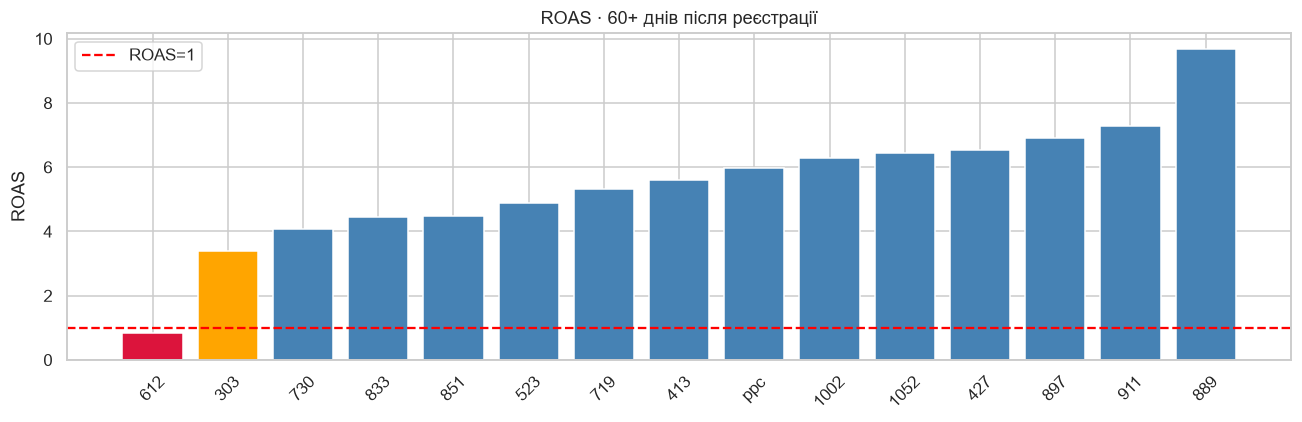

In [23]:
roas = q("""
WITH mx AS (SELECT MAX(date_created) AS max_payment_date FROM pay),
costs AS (
 SELECT network,
        SUM(cost) AS spend,
        SUM(cost) FILTER (
          WHERE date_created<=mx.max_payment_date-INTERVAL 60 DAY
        ) AS cohort_60dplus_spend
 FROM reg CROSS JOIN mx GROUP BY 1
),
rev AS (
 SELECT r.network,
        SUM(p.amount) FILTER (WHERE p.status='success')
          - SUM(p.amount) FILTER (
              WHERE p.status='success' AND p.chargeback_date IS NOT NULL
            ) AS net_revenue,
        SUM(p.amount) FILTER (
          WHERE p.status='success'
            AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
        ) - SUM(p.amount) FILTER (
          WHERE p.status='success'
            AND p.chargeback_date IS NOT NULL
            AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
        ) AS cohort_60dplus_net_revenue
 FROM pay p
 JOIN reg r USING(id_user)
 CROSS JOIN mx
 GROUP BY 1
)
SELECT c.network,ROUND(c.spend,0) AS spend,
       ROUND(r.net_revenue,0) AS net_revenue,
       ROUND(r.net_revenue/NULLIF(c.spend,0),2) AS roas,
       ROUND(r.net_revenue-c.spend,0) AS profit,
       ROUND(
         r.cohort_60dplus_net_revenue/NULLIF(c.cohort_60dplus_spend,0),2
       ) AS roas_cohort_60dplus
FROM costs c
JOIN rev r USING(network)
WHERE c.spend IS NOT NULL
ORDER BY roas_cohort_60dplus
""")
display(roas)

d=roas.sort_values('roas_cohort_60dplus')
fig,ax=plt.subplots(figsize=(12,4))
ax.bar(
    d.network.astype(str),d.roas_cohort_60dplus,
    color=[
      'crimson' if x<1 else ('orange' if x<3.5 else 'steelblue')
      for x in d.roas_cohort_60dplus
    ]
)
ax.axhline(1,color='red',ls='--',label='ROAS=1')
ax.set_title('ROAS · 60+ днів після реєстрації')
ax.set_ylabel('ROAS')
ax.tick_params(axis='x',rotation=45); ax.legend()
plt.tight_layout(); plt.show()


**Бізнес-логіка**

- `612` — підтверджений фрод і збиток: припинити співпрацю.
- `1052` — кардинг, але портфель залишається прибутковим: затримка виплат
  на 60 днів, резерв, зниження ставки та платіжні обмеження.
- `523/911` — прибутковий, але підозрілий мотивований трафік: не масштабувати
  до завершення перевірки, переглянути ставку й умови якості.
- `719` — можлива повторна атрибуція вже відомих користувачів: перевірити
  вікно атрибуції та правила оплати повторних `id_metauser`.
- `1002/889` — прибуткові CPS-партнери з ризиком переплати: не відключати,
  але перейти до контролю за D60/LTV.

## 14. Журнал перевірених гіпотез

Анна окремо наголошувала, що важливий не лише фінальний список мереж, а й хід думок. Тому зберігаю підтверджені, спростовані та неперевірювані на цих даних гіпотези.


In [24]:
hypothesis_log = pd.DataFrame([
 {'id':'H1','network':'усі CPA','hypothesis':'Реєстрації створюються механічно через однакові інтервали',
  'check':'добовий ритм; інтервали 5/10/15/60 секунд; порівняння з ppc',
  'result':'частково','conclusion':'833 і 523 потребують перевірки, але ботів не доведено'},
 {'id':'H2','network':'523','hypothesis':'Мотивований трафік реєструється за винагороду і не користується продуктом',
  'check':'D7; відсутність сесій; одна сесія; credits після оплати',
  'result':'candidate','conclusion':'кілька незалежних сигналів; не масштабувати'},
 {'id':'H3','network':'911','hypothesis':'Мотивований трафік реєструється за винагороду і не користується продуктом',
  'check':'D7; відсутність сесій; одна сесія; credits після оплати',
  'result':'candidate','conclusion':'кілька незалежних сигналів; умови якості'},
 {'id':'H4','network':'523/911/851','hypothesis':'Один id_metauser масово створює нові акаунти',
  'check':'частка повторних metauser; p99; максимум; порівняння з ppc',
  'result':'спростовано','conclusion':'масовий цикл реєстрацій не підтвердився'},
 {'id':'H5','network':'affiliate','hypothesis':'Ботів можна об’єднати за однаковим user-agent або email',
  'check':'повнота user_agent; структура email',
  'result':'неможливо перевірити','conclusion':'user_agent відсутній, email анонімізовано'},
 {'id':'H6','network':'719','hypothesis':'Партнер отримує оплату за вже відомих продукту користувачів',
  'check':'перше джерело metauser; частка spend; CR; час до повторної реєстрації',
  'result':'candidate','conclusion':'сильний сигнал, але потрібні правила attribution window'},
 {'id':'H7','network':'1052','hypothesis':'Партнер приводить оплати з крадених карток',
  'check':'chargeback count/amount, 60+ days since payment; збиток; швидкість спроб',
  'result':'підтверджено','conclusion':'кардинг; holdback і резерв'},
 {'id':'H8','network':'612','hypothesis':'Кардинг поєднаний із CPS churn-and-burn',
  'check':'chargeback; одна оплата; cost > net revenue; ROAS',
  'result':'підтверджено','conclusion':'припинити співпрацю'},
 {'id':'H9','network':'усі','hypothesis':'Партнери підміняють дешеву країну під Tier-1',
  'check':'країна реєстрації проти країни платежу; baseline ppc',
  'result':'спростовано','conclusion':'систематичної підміни немає'},
 {'id':'H10','network':'1002/889','hypothesis':'CPS-партнери створюють мінімальну оплату та зникають',
  'check':'одна оплата; перший чек; cost > revenue; credits; ROAS',
  'result':'не підтверджено','conclusion':'ризик переплати є, масового фроду не доведено'},
 {'id':'H11','network':'303','hypothesis':'Низька активність є мотивованим трафіком',
  'check':'покриття activity_log; D7; сесії; credits',
  'result':'спростовано','conclusion':'після виправлення покриття профіль близький до норми'},
])
display(hypothesis_log)


,id,network,hypothesis,check,result,conclusion
0,H1,усі CPA,Реєстрації створюються механічно через однаков...,добовий ритм; інтервали 5/10/15/60 секунд; пор...,частково,"833 і 523 потребують перевірки, але ботів не д..."
1,H2,523,Мотивований трафік реєструється за винагороду ...,D7; відсутність сесій; одна сесія; credits піс...,candidate,кілька незалежних сигналів; не масштабувати
2,H3,911,Мотивований трафік реєструється за винагороду ...,D7; відсутність сесій; одна сесія; credits піс...,candidate,кілька незалежних сигналів; умови якості
3,H4,523/911/851,Один id_metauser масово створює нові акаунти,частка повторних metauser; p99; максимум; порі...,спростовано,масовий цикл реєстрацій не підтвердився
4,H5,affiliate,Ботів можна об’єднати за однаковим user-agent ...,повнота user_agent; структура email,неможливо перевірити,"user_agent відсутній, email анонімізовано"
5,H6,719,Партнер отримує оплату за вже відомих продукту...,перше джерело metauser; частка spend; CR; час ...,candidate,"сильний сигнал, але потрібні правила attributi..."
6,H7,1052,Партнер приводить оплати з крадених карток,"chargeback count/amount, 60+ days since paymen...",підтверджено,кардинг; holdback і резерв
7,H8,612,Кардинг поєднаний із CPS churn-and-burn,chargeback; одна оплата; cost > net revenue; ROAS,підтверджено,припинити співпрацю
8,H9,усі,Партнери підміняють дешеву країну під Tier-1,країна реєстрації проти країни платежу; baseli...,спростовано,систематичної підміни немає
9,H10,1002/889,CPS-партнери створюють мінімальну оплату та зн...,одна оплата; перший чек; cost > revenue; credi...,не підтверджено,"ризик переплати є, масового фроду не доведено"


## 15. Фінальна таблиця доказів

Статуси мають різну силу:

- `confirmed` — механізм підтверджено кількома незалежними джерелами;
- `candidate` — є сильні сигнали, але залишається правдоподібне альтернативне пояснення;
- `watchlist` — ризик варто контролювати, доказів фроду недостатньо;
- `not confirmed` — суттєвих доказів немає або гіпотезу спростовано.


In [25]:
summary = (
    behavior_scorecard
    .merge(
        pay_scorecard[[
          'network','cb_count_rate_payment_60dplus','cb_amount_rate_payment_60dplus','cb_lost_usd',
          'p99_attempts','users_with_gap_le_60s'
        ]],
        on='network',how='left'
    )
    .merge(
        roas[['network','spend','roas','roas_cohort_60dplus']],
        on='network',how='left'
    )
    .merge(
        cps_scorecard[[
          'network','one_payment_share_cohort_60dplus','share_cost_gt_net'
        ]],
        on='network',how='left'
    )
    .merge(
        attribution_scorecard[[
          'network','prior_clean_share','prior_clean_share_costed',
          'spend_share_prior_clean','cr_lift_prior_clean'
        ]],
        on='network',how='left'
    )
)

verdicts = {
 '612':  ('confirmed','кардинг + зловживання CPS','high',
          'припинити співпрацю; переглянути невиплачені конверсії'),
 '1052': ('confirmed','кардинг','high',
          'затримка виплат 60 днів; резерв; перегляд ставки'),
 '523':  ('candidate','мотивований трафік + можлива автоматизація','high',
          'не масштабувати; перевірити джерела; знизити ставку'),
 '911':  ('candidate','мотивований трафік','high',
          'не масштабувати; додати умови якості'),
 '719':  ('candidate','можлива повторна атрибуція','medium',
          'перевірити attribution window і повторні id_metauser'),
 '833':  ('watchlist','часовий сигнал автоматизації','low',
          'зібрати другий сигнал; залишити на контролі'),
 '851':  ('watchlist','слабка залученість','medium',
          'контроль у розрізі країни та місяця'),
 '1002': ('watchlist','ризик переплати в CPS','medium',
          'контроль виплат після 60+ днів від реєстрації / LTV'),
 '889':  ('watchlist','ризик переплати в CPS','medium',
          'контроль виплат після 60+ днів від реєстрації / LTV'),
 '303':  ('not confirmed','гіпотезу мотивованого трафіку спростовано','low',
          'дії щодо фроду не потрібні'),
}
for n in summary.network.astype(str):
    verdicts.setdefault(
        n,
        ('not confirmed','суттєвих доказів фроду немає','low',
         'стандартний контроль')
    )

v = pd.DataFrame([
    {
      'network':n,'status':x[0],'fraud_type':x[1],
      'confidence':x[2],'action':x[3]
    }
    for n,x in verdicts.items()
])
summary = summary.merge(v,on='network',how='left')
status_order={'confirmed':0,'candidate':1,'watchlist':2,'not confirmed':3}
summary['status_order']=summary.status.map(status_order)
summary=summary.sort_values(
    ['status_order','cb_lost_usd'],ascending=[True,False]
).drop(columns='status_order')

final_view=summary[[
    'network','status','fraud_type','confidence',
    'pct_no_session','retention_d7','one_session_share_active',
    'payer_no_credit_use','cb_amount_rate_payment_60dplus',
    'prior_clean_share_costed','one_payment_share_cohort_60dplus',
    'roas_cohort_60dplus','action'
]]
display(final_view.round({
 'pct_no_session':3,'retention_d7':3,'one_session_share_active':3,
 'payer_no_credit_use':3,'cb_amount_rate_payment_60dplus':4,
 'prior_clean_share_costed':3,'one_payment_share_cohort_60dplus':3,
 'roas_cohort_60dplus':2
}))


,network,status,fraud_type,confidence,pct_no_session,retention_d7,one_session_share_active,payer_no_credit_use,cb_amount_rate_payment_60dplus,prior_clean_share_costed,one_payment_share_cohort_60dplus,roas_cohort_60dplus,action
4,1052,confirmed,кардинг,high,0.123,0.058,0.379,0.000,0.212,0.019,0.471,6.440,затримка виплат 60 днів; резерв; перегляд ставки
8,612,confirmed,кардинг + зловживання CPS,high,0.152,0.066,0.358,0.000,0.121,0.056,0.907,0.850,припинити співпрацю; переглянути невиплачені к...
13,719,candidate,можлива повторна атрибуція,medium,0.158,0.078,0.308,0.000,0.003,0.157,NaN,5.330,перевірити attribution window і повторні id_me...
2,523,candidate,мотивований трафік + можлива автоматизація,high,0.239,0.022,0.595,0.119,0.004,0.015,NaN,4.890,не масштабувати; перевірити джерела; знизити с...
0,911,candidate,мотивований трафік,high,0.236,0.015,0.632,0.078,0.008,0.020,NaN,7.290,не масштабувати; додати умови якості
9,1002,watchlist,ризик переплати в CPS,medium,0.080,0.068,0.332,0.000,0.004,0.021,0.475,6.280,контроль виплат після 60+ днів від реєстрації ...
3,833,watchlist,часовий сигнал автоматизації,low,0.187,0.041,0.415,0.000,0.004,0.021,NaN,4.450,зібрати другий сигнал; залишити на контролі
15,889,watchlist,ризик переплати в CPS,medium,0.132,0.089,0.298,0.000,0.002,0.065,0.530,9.690,контроль виплат після 60+ днів від реєстрації ...
1,851,watchlist,слабка залученість,medium,0.187,0.019,0.603,0.000,0.007,0.013,NaN,4.490,контроль у розрізі країни та місяця
14,ppc,not confirmed,суттєвих доказів фроду немає,low,0.158,0.078,0.324,0.000,0.004,0.010,0.476,5.960,стандартний контроль


## 16. Картки рішень

### 612 — підтверджений фрод, висока впевненість

- **Механізм:** кардинг разом зі зловживанням CPS.
- **Докази:** екстремальний chargeback; серед платників, від реєстрації яких минуло 60+ днів, близько 91% мають одну оплату; виплата партнеру майже завжди перевищує дохід від користувача; ROAS нижче 1.
- **Дія:** припинити співпрацю та переглянути невиплачені конверсії.

### 1052 — підтверджений кардинг, висока впевненість

- **Механізм:** великі платежі з крадених карток згодом повертаються банку.
- **Докази:** найбільша частка поверненої суми, близько $1.5M втрат, аномалія зберігається серед платежів, від яких минуло 60+ днів; часті короткі серії платіжних спроб.
- **Дія:** затримка виплат на 60 днів, резерв під повернення, платіжні обмеження та перегляд ставки. Автоматично не відключати, бо партнер залишається прибутковим.

### 523 — сильний кандидат

- **Механізм:** мотивований трафік із можливою домішкою автоматизації.
- **Докази:** мало активних на сьомий день, багато користувачів без сесій і лише з однією сесією, частина платників не використовує credits, у кількох країнах є стійко слабкий нічний спад.
- **Дія:** не масштабувати, попросити розкриття джерел трафіку та знизити ставку до підтвердження якості.

### 911 — сильний кандидат

- **Механізм:** мотивоване залучення користувачів за винагороду.
- **Докази:** активність на сьомий день, глибина сесій та використання credits гірші за `ppc`.
- **Дія:** не масштабувати, додати умови якості та контроль у розрізі країни й місяця.

### 719 — кандидат на повторну атрибуцію

- **Механізм:** партнер може отримувати оплату за користувачів, яких раніше вже залучили `ppc/organic`.
- **Докази:** 13.3% раніше відомих користувачів, 16.6% витрат на них, конверсія у 1.8 раза вища за нових.
- **Альтернативне пояснення:** дозволений ретаргетинг або повторне залучення.
- **Дія:** перевірити attribution window і правила оплати повторних `id_metauser`.

### Відкриті та спростовані гіпотези

- `833`: є часовий сигнал автоматизації, але немає другого незалежного доказу.
- `851`: слабка залученість, але недостатньо доказів фроду.
- `1002/889`: є ризик переплати в CPS, але користувачі витрачають credits, а партнери прибуткові.
- `303`: гіпотезу мотивованого трафіку спростовано після виправлення покриття `activity_log`.
- систематичну підміну країни не підтверджено;
- однаковий user-agent та шаблони email неможливо перевірити через обмеження даних.


## 17. Операційний моніторинг

Головний підсумковий показник для команди — **ROAS когорт, від реєстрації яких минуло 60+ днів, після вирахування chargeback**.

Він показує, чи окупається партнер після того, як більша частина пізніх проблем уже стала видимою. Для раннього виявлення причини використовую окремі сигнали: chargeback за платежами, від яких минуло 60+ днів, D7, відсутність сесій, повторну атрибуцію та стійко слабкий нічний спад.


In [26]:
monitoring = pd.DataFrame([
 {'signal':'ROAS · 60+ днів після реєстрації','window':'щотижня; 60+ днів після реєстрації',
  'threshold':'червоний < 1; жовтий < 70% зіставного baseline',
  'min_sample':'витрати партнера ≥ $10k',
  'action':'відключити або переглянути ставку'},
 {'signal':'Частка chargeback за сумою · 60+ днів після платежу',
  'window':'щотижня; 60+ днів після платежу',
  'threshold':'max(2%, 3× ppc)','min_sample':'≥ 1 000 успішних платежів',
  'action':'затримка виплат, резерв, перевірка платежів'},
 {'signal':'D7 та відсутність сесій проти ppc',
  'window':'країна × місяць реєстрації',
  'threshold':'D7 < 0.6× ppc і no-session > 1.3× ppc',
  'min_sample':'≥ 500 реєстрацій у партнера та ppc',
  'action':'не масштабувати; перевірити джерела'},
 {'signal':'Повторна атрибуція відомих користувачів',
  'window':'мережа × місяць реєстрації',
  'threshold':'частка серед оплачених > max(5%, 3× ppc)',
  'min_sample':'≥ 1 000 оплачених реєстрацій',
  'action':'перевірити attribution window та повторні id_metauser'},
 {'signal':'Стійко слабкий нічний спад',
  'window':'країна × тиждень',
  'threshold':'відношення > 1.3 у ≥50% з ≥4 перевірених тижнів',
  'min_sample':'≥ 1 000 реєстрацій/тиждень у партнера та ppc',
  'action':'перевірка автоматизації; потрібен другий сигнал'},
])
display(monitoring)


,signal,window,threshold,min_sample,action
0,ROAS · 60+ днів після реєстрації,щотижня; 60+ днів після реєстрації,червоний < 1; жовтий < 70% зіставного baseline,витрати партнера ≥ $10k,відключити або переглянути ставку
1,Частка chargeback за сумою · 60+ днів після пл...,щотижня; 60+ днів після платежу,"max(2%, 3× ppc)",≥ 1 000 успішних платежів,"затримка виплат, резерв, перевірка платежів"
2,D7 та відсутність сесій проти ppc,країна × місяць реєстрації,D7 < 0.6× ppc і no-session > 1.3× ppc,≥ 500 реєстрацій у партнера та ppc,не масштабувати; перевірити джерела
3,Повторна атрибуція відомих користувачів,мережа × місяць реєстрації,"частка серед оплачених > max(5%, 3× ppc)",≥ 1 000 оплачених реєстрацій,перевірити attribution window та повторні id_m...
4,Стійко слабкий нічний спад,країна × тиждень,відношення > 1.3 у ≥50% з ≥4 перевірених тижнів,≥ 1 000 реєстрацій/тиждень у партнера та ppc,перевірка автоматизації; потрібен другий сигнал


## 18. Фінальний висновок

Найсильніші підтверджені фродові мережі — `612` і `1052`.

`523` та `911` мають кілька незалежних ознак мотивованого трафіку й потребують комерційних обмежень та перевірки джерел. `719` має сильний сигнал повторної атрибуції вже відомих користувачів, але до перевірки attribution window залишається кандидатом, а не підтвердженим фродом.

`833`, `851`, `1002` і `889` залишаються гіпотезами або ризиками різної природи. `303` після коректного врахування покриття `activity_log` виключено зі списку підозрілих.

Ключовий принцип: висновок про фрод і бізнес-рішення — не одне й те саме. Збитковий підтверджений фрод відключаємо. Прибутковий, але ризиковий трафік переводимо на затримку виплат, нижчу ставку, контроль за LTV та посилений моніторинг.


## 19. Експорт даних до Power BI

Модель:

- `network_summary` — один рядок на мережу, головні показники та рішення;
- `fact_network_month` — економіка когорт за місяцем реєстрації;
- `fact_econ_country` — адитивна юніт-економіка `network × country × cohort_month`;
- `fact_behavior_segment` — поведінка `network × country × month` проти
  зіставного `ppc`;
- `fact_bot_weekly` — часові сигнали `network × country × week`;
- `fact_attribution_month` — повторна атрибуція за мережею та місяцем;
- `fact_fraud_alerts` — готовий перелік сигналів для команди;
- `dim_date` і `monitoring_rules` — календар та правила контролю.

In [27]:
# --- 19.1 Вітрини для Power BI ---
POWERBI_DATA = PROJECT / "powerbi_data"
POWERBI_DATA.mkdir(exist_ok=True)

# 1) Одна строка на мережу.
network_summary = summary.copy()
network_summary["network"] = network_summary["network"].astype(str)
payment_models = {
    "612":"CPS","889":"CPS","1002":"CPS","1052":"змішана CPA",
    "ppc":"внутрішня закупівля","organic":"органічний трафік",
}
network_summary["payment_model"] = network_summary["network"].map(
    lambda n: payment_models.get(n,"CPA")
)
network_summary = network_summary[[
    "network","payment_model","status","fraud_type","confidence","action",
    "regs","valid_activity_regs","pct_no_session","retention_d7",
    "one_session_share_active","same_duration_share_multi",
    "med_sessions","med_duration_sec","payer_no_credit_use","cr_pay",
    "cb_count_rate_payment_60dplus","cb_amount_rate_payment_60dplus","cb_lost_usd",
    "p99_attempts","users_with_gap_le_60s",
    "prior_clean_share","prior_clean_share_costed",
    "spend_share_prior_clean","cr_lift_prior_clean",
    "one_payment_share_cohort_60dplus","share_cost_gt_net",
    "spend","roas","roas_cohort_60dplus"
]].sort_values(["status","network"]).reset_index(drop=True)

# 2) Економіка network × місяць реєстрації.
fact_network_month = q("""
WITH mx AS (SELECT MAX(date_created) AS max_payment_date FROM pay),
reg_m AS (
  SELECT r.network,
         CAST(date_trunc('month',r.date_created) AS DATE) AS cohort_month,
         COUNT(*) AS registrations,
         COUNT(*) FILTER (WHERE r.cost IS NOT NULL) AS costed_registrations,
         SUM(r.cost) AS spend,
         COUNT(*) FILTER (
           WHERE r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_registrations,
         SUM(r.cost) FILTER (
           WHERE r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_spend
  FROM reg r CROSS JOIN mx
  GROUP BY 1,2
),
pay_m AS (
  SELECT r.network,
         CAST(date_trunc('month',r.date_created) AS DATE) AS cohort_month,
         COUNT(DISTINCT p.id_user) FILTER (WHERE p.status='success') AS payers,
         SUM(p.amount) FILTER (WHERE p.status='success') AS gross_revenue,
         SUM(p.amount) FILTER (
           WHERE p.status='success' AND p.chargeback_date IS NOT NULL
         ) AS chargeback_amount,
         SUM(p.amount) FILTER (
           WHERE p.status='success'
             AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_gross_revenue,
         SUM(p.amount) FILTER (
           WHERE p.status='success' AND p.chargeback_date IS NOT NULL
             AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_chargeback_amount
  FROM pay p
  JOIN reg r USING(id_user)
  CROSS JOIN mx
  GROUP BY 1,2
)
SELECT r.network,r.cohort_month,r.registrations,r.costed_registrations,
       ROUND(COALESCE(r.spend,0),2) AS spend,
       r.cohort_60dplus_registrations,
       ROUND(COALESCE(r.cohort_60dplus_spend,0),2) AS cohort_60dplus_spend,
       COALESCE(p.payers,0) AS payers,
       ROUND(COALESCE(p.gross_revenue,0),2) AS gross_revenue,
       ROUND(COALESCE(p.chargeback_amount,0),2) AS chargeback_amount,
       ROUND(COALESCE(p.gross_revenue,0)-COALESCE(p.chargeback_amount,0),2)
         AS net_revenue,
       ROUND(
         (COALESCE(p.gross_revenue,0)-COALESCE(p.chargeback_amount,0))
         / NULLIF(r.spend,0),3
       ) AS roas,
       ROUND(COALESCE(p.cohort_60dplus_gross_revenue,0),2)
         AS cohort_60dplus_gross_revenue,
       ROUND(COALESCE(p.cohort_60dplus_chargeback_amount,0),2)
         AS cohort_60dplus_chargeback_amount,
       ROUND(
         COALESCE(p.cohort_60dplus_gross_revenue,0)
         - COALESCE(p.cohort_60dplus_chargeback_amount,0),2
       ) AS cohort_60dplus_net_revenue,
       ROUND(
         (
           COALESCE(p.cohort_60dplus_gross_revenue,0)
           - COALESCE(p.cohort_60dplus_chargeback_amount,0)
         ) / NULLIF(r.cohort_60dplus_spend,0),3
       ) AS roas_cohort_60dplus
FROM reg_m r
LEFT JOIN pay_m p USING(network,cohort_month)
ORDER BY cohort_month,network
""")

# 3) Адитивна економіка network × країна реєстрації × місяць реєстрації.
# Країна платежу тут свідомо не використовується: якість та spend належать
# трафіку, який партнер привів у країні реєстрації.
# UNKNOWN зберігає повну адитивність для реєстрацій без country.
fact_econ_country = q("""
WITH mx AS (SELECT MAX(date_created) AS max_payment_date FROM pay),
reg_c AS (
  SELECT CAST(r.network AS VARCHAR) AS network,
         COALESCE(CAST(r.country AS VARCHAR),'UNKNOWN') AS country,
         CAST(date_trunc('month',r.date_created) AS DATE) AS cohort_month,
         COUNT(*) AS registrations,
         COUNT(*) FILTER (WHERE r.cost IS NOT NULL) AS costed_registrations,
         SUM(r.cost) AS spend,
         COUNT(*) FILTER (
           WHERE r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_registrations,
         SUM(r.cost) FILTER (
           WHERE r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_spend
  FROM reg r CROSS JOIN mx
  GROUP BY 1,2,3
),
pay_c AS (
  SELECT CAST(r.network AS VARCHAR) AS network,
         COALESCE(CAST(r.country AS VARCHAR),'UNKNOWN') AS country,
         CAST(date_trunc('month',r.date_created) AS DATE) AS cohort_month,
         COUNT(DISTINCT p.id_user) FILTER (WHERE p.status='success') AS payers,
         SUM(p.amount) FILTER (WHERE p.status='success') AS gross_revenue,
         SUM(p.amount) FILTER (
           WHERE p.status='success' AND p.chargeback_date IS NOT NULL
         ) AS chargeback_amount,
         SUM(p.amount) FILTER (
           WHERE p.status='success'
             AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_gross_revenue,
         SUM(p.amount) FILTER (
           WHERE p.status='success' AND p.chargeback_date IS NOT NULL
             AND r.date_created<=mx.max_payment_date-INTERVAL 60 DAY
         ) AS cohort_60dplus_chargeback_amount
  FROM pay p
  JOIN reg r USING(id_user)
  CROSS JOIN mx
  GROUP BY 1,2,3
)
SELECT r.network,r.country,r.cohort_month,
       r.registrations,r.costed_registrations,
       COALESCE(r.spend,0) AS spend,
       r.cohort_60dplus_registrations,
       COALESCE(r.cohort_60dplus_spend,0) AS cohort_60dplus_spend,
       COALESCE(p.payers,0) AS payers,
       COALESCE(p.gross_revenue,0) AS gross_revenue,
       COALESCE(p.gross_revenue,0)-COALESCE(p.chargeback_amount,0)
         AS net_revenue,
       COALESCE(p.chargeback_amount,0) AS chargeback_amount,
       COALESCE(p.cohort_60dplus_gross_revenue,0) AS cohort_60dplus_gross_revenue,
       COALESCE(p.cohort_60dplus_gross_revenue,0)
         - COALESCE(p.cohort_60dplus_chargeback_amount,0) AS cohort_60dplus_net_revenue,
       COALESCE(p.cohort_60dplus_chargeback_amount,0) AS cohort_60dplus_chargeback_amount,
       CASE WHEN r.registrations>=500 THEN TRUE ELSE FALSE END AS sample_ok
FROM reg_c r
LEFT JOIN pay_c p USING(network,country,cohort_month)
ORDER BY cohort_month,network,country
""")
fact_econ_country["network"] = fact_econ_country["network"].astype(str)

# Контроль адитивності проти чинного fact_network_month.
country_qc = (
    fact_econ_country.groupby(["network","cohort_month"],as_index=False)
    .agg(spend_country=("spend","sum"),
         net_revenue_country=("net_revenue","sum"),
         payers_country=("payers","sum"))
    .merge(
      fact_network_month[["network","cohort_month","spend","net_revenue","payers"]],
      on=["network","cohort_month"],how="outer",validate="one_to_one"
    )
)
country_qc["spend_diff"] = (
    country_qc["spend_country"].round(2)-country_qc["spend"].round(2)
)
country_qc["net_revenue_diff"] = (
    country_qc["net_revenue_country"].round(2)
    - country_qc["net_revenue"].round(2)
)
country_qc["payers_diff"] = country_qc["payers_country"]-country_qc["payers"]
# Допуск 1 цент потрібен лише через округлення чинного fact_network_month.
assert country_qc[["spend_diff","net_revenue_diff"]].abs().to_numpy().max()<=0.011
assert country_qc["payers_diff"].abs().max()==0

# 4) Поведінка в однакових країнах і місяцях.
fact_behavior_segment = q("""
WITH mx AS (SELECT MAX(date_start) AS max_activity_date FROM act),
base AS (
  SELECT r.network,r.country,
         CAST(date_trunc('month',r.date_created) AS DATE) AS cohort_month,
         COUNT(*) AS registrations,
         AVG(CASE WHEN s.id_user IS NULL THEN 1.0 ELSE 0.0 END)
           AS no_session_rate,
         AVG(CASE WHEN r.date_created<=mx.max_activity_date-INTERVAL 7 DAY
                  THEN COALESCE(s.retained_d7,0) END) AS d7_rate,
         MEDIAN(s.n_sessions) AS med_sessions
  FROM reg r
  LEFT JOIN post_session_user s USING(id_user)
  JOIN activity_coverage c
    ON date_trunc('month',r.date_created)=c.registration_month
  CROSS JOIN mx
  WHERE c.ppc_post_session_rate>=0.10 AND r.country IS NOT NULL
  GROUP BY 1,2,3
),
ppc AS (
  SELECT country,cohort_month,registrations AS ppc_registrations,
         no_session_rate AS ppc_no_session_rate,d7_rate AS ppc_d7_rate
  FROM base WHERE network='ppc'
)
SELECT b.network,b.country,b.cohort_month,b.registrations,
       ROUND(b.no_session_rate,4) AS no_session_rate,
       ROUND(b.d7_rate,4) AS d7_rate,
       ROUND(b.med_sessions,1) AS med_sessions,
       p.ppc_registrations,
       ROUND(p.ppc_no_session_rate,4) AS ppc_no_session_rate,
       ROUND(p.ppc_d7_rate,4) AS ppc_d7_rate,
       ROUND(b.no_session_rate/NULLIF(p.ppc_no_session_rate,0),3)
         AS no_session_ratio,
       ROUND(b.d7_rate/NULLIF(p.ppc_d7_rate,0),3) AS d7_ratio,
       CASE WHEN b.registrations>=500 AND p.ppc_registrations>=500
            THEN TRUE ELSE FALSE END AS sample_ok,
       CASE WHEN b.network NOT IN ('ppc','organic')
                  AND b.registrations>=500 AND p.ppc_registrations>=500
                  AND b.no_session_rate>p.ppc_no_session_rate*1.30
                  AND b.d7_rate<p.ppc_d7_rate*0.60
            THEN TRUE ELSE FALSE END AS incentivized_alert
FROM base b
LEFT JOIN ppc p USING(country,cohort_month)
ORDER BY cohort_month,network,country
""")

# 5) Часові сигнали.
fact_bot_weekly = screen.copy()
fact_bot_weekly["network"] = fact_bot_weekly["network"].astype(str)
fact_bot_weekly["week"] = pd.to_datetime(fact_bot_weekly["week"]).dt.date
fact_bot_weekly["hourly_alert"] = fact_bot_weekly["ratio_to_ppc"]>1.30

# 6) Повторна атрибуція network × month.
fact_attribution_month = q("""
SELECT network,
       CAST(date_trunc('month',date_created) AS DATE) AS cohort_month,
       COUNT(*) AS registrations,
       COUNT(*) FILTER (WHERE cost IS NOT NULL) AS costed_registrations,
       ROUND(SUM(COALESCE(cost,0)),2) AS spend,
       ROUND(SUM(COALESCE(cost,0)) FILTER (WHERE prior_clean),2)
         AS spend_prior_clean,
       ROUND(AVG(prior_clean::INTEGER),4) AS prior_clean_share,
       ROUND(AVG(prior_clean::INTEGER) FILTER (WHERE cost IS NOT NULL),4)
         AS prior_clean_share_costed,
       ROUND(SUM(cost) FILTER (WHERE prior_clean)/NULLIF(SUM(cost),0),4)
         AS spend_share_prior_clean,
       ROUND(AVG(paid::INTEGER) FILTER (WHERE prior_clean),4) AS cr_prior_clean,
       ROUND(AVG(paid::INTEGER) FILTER (WHERE NOT prior_clean),4) AS cr_other
FROM attribution_registration
GROUP BY 1,2
ORDER BY cohort_month,network
""")

# 7) Календар.
date_min = pd.to_datetime(fact_network_month["cohort_month"]).min()
date_max = (
    pd.to_datetime(fact_network_month["cohort_month"]).max()
    + pd.offsets.MonthEnd(1)
)
dim_date = pd.DataFrame({"date":pd.date_range(date_min,date_max,freq="D")})
dim_date["year"] = dim_date["date"].dt.year
dim_date["month_number"] = dim_date["date"].dt.month
dim_date["month_start"] = dim_date["date"].dt.to_period("M").dt.to_timestamp()
dim_date["month_label"] = dim_date["date"].dt.strftime("%Y-%m")
dim_date["week_start"] = (
    dim_date["date"]
    - pd.to_timedelta(dim_date["date"].dt.weekday,unit="D")
)

# 8) Єдина таблиця сигналів.
action_map = network_summary.set_index("network")["action"].to_dict()
alert_rows = []
ppc_roas = network_summary.loc[
    network_summary.network=="ppc","roas_cohort_60dplus"
].iloc[0]
ppc_cb = network_summary.loc[
    network_summary.network=="ppc","cb_amount_rate_payment_60dplus"
].iloc[0]
ppc_attr = network_summary.loc[
    network_summary.network=="ppc","prior_clean_share_costed"
].iloc[0]
cb_threshold = max(0.02,3*ppc_cb)
attr_threshold = max(0.05,3*ppc_attr)

for _,r in network_summary.iterrows():
    n=str(r.network)
    if n not in ("ppc","organic"):
        alert_rows.append({
          "network":n,"country":"ALL","signal":"ROAS · 60+ днів після реєстрації",
          "metric_value":r.roas_cohort_60dplus,"secondary_value":np.nan,
          "baseline":ppc_roas,"threshold":1.0,"sample_size":r.spend,
          "is_alert":bool(
            pd.notna(r.roas_cohort_60dplus) and r.roas_cohort_60dplus<1
          ),
          "severity":"red" if pd.notna(r.roas_cohort_60dplus)
                                 and r.roas_cohort_60dplus<1 else "green",
          "action":action_map.get(n,"стандартний контроль"),
        })
        alert_rows.append({
          "network":n,"country":"ALL",
          "signal":"Chargeback за сумою · 60+ днів після платежу",
          "metric_value":r.cb_amount_rate_payment_60dplus,"secondary_value":np.nan,
          "baseline":ppc_cb,"threshold":cb_threshold,"sample_size":r.regs,
          "is_alert":bool(
            pd.notna(r.cb_amount_rate_payment_60dplus)
            and r.cb_amount_rate_payment_60dplus>cb_threshold
          ),
          "severity":"red" if pd.notna(r.cb_amount_rate_payment_60dplus)
                                 and r.cb_amount_rate_payment_60dplus>cb_threshold
                              else "green",
          "action":action_map.get(n,"стандартний контроль"),
        })
        attr_alert = bool(
          pd.notna(r.prior_clean_share_costed)
          and r.prior_clean_share_costed>attr_threshold
          and pd.notna(r.spend_share_prior_clean)
          and r.spend_share_prior_clean>0.05
        )
        alert_rows.append({
          "network":n,"country":"ALL","signal":"Повторна атрибуція",
          "metric_value":r.prior_clean_share_costed,
          "secondary_value":r.spend_share_prior_clean,
          "baseline":ppc_attr,"threshold":attr_threshold,
          "sample_size":r.regs,"is_alert":attr_alert,
          "severity":"orange" if attr_alert else "green",
          "action":action_map.get(n,"стандартний контроль"),
        })

for _,r in behavior_relative.iterrows():
    n=str(r.network)
    is_alert=bool(r.med_d7_ratio<0.60 and r.med_no_session_ratio>1.30)
    alert_rows.append({
      "network":n,"country":"ALL","signal":"D7 + відсутність сесій",
      "metric_value":r.med_d7_ratio,
      "secondary_value":r.med_no_session_ratio,
      "baseline":1.0,"threshold":0.60,
      "sample_size":r.comparable_segments,"is_alert":is_alert,
      "severity":"orange" if is_alert else "green",
      "action":action_map.get(n,"стандартний контроль"),
    })

bot_network_country = weekly_summary.copy()
bot_network_country["persistence_share"] = (
    bot_network_country["weeks_ratio_gt_1_3"]
    / bot_network_country["checked_weeks"].replace(0,np.nan)
)
for _,r in bot_network_country.iterrows():
    if r.checked_weeks>=4:
        is_alert=bool(r.persistence_share>=0.50)
        alert_rows.append({
          "network":str(r.network),"country":str(r.country),
          "signal":"Стійко слабкий нічний спад",
          "metric_value":r.persistence_share,
          "secondary_value":r.median_ratio,
          "baseline":0.0,"threshold":0.50,
          "sample_size":r.checked_weeks,"is_alert":is_alert,
          "severity":"orange" if is_alert else "green",
          "action":action_map.get(str(r.network),"перевірка автоматизації"),
        })

fact_fraud_alerts = pd.DataFrame(alert_rows)

# 9) Експорт дев'яти CSV.
powerbi_exports = {
    "network_summary":network_summary,
    "fact_network_month":fact_network_month,
    "fact_econ_country":fact_econ_country,
    "fact_behavior_segment":fact_behavior_segment,
    "fact_bot_weekly":fact_bot_weekly,
    "fact_attribution_month":fact_attribution_month,
    "fact_fraud_alerts":fact_fraud_alerts,
    "dim_date":dim_date,
    "monitoring_rules":monitoring,
}

export_manifest=[]
for name,df in powerbi_exports.items():
    path=POWERBI_DATA/f"{name}.csv"
    df.to_csv(path,index=False,encoding="utf-8-sig",date_format="%Y-%m-%d")
    export_manifest.append({
      "table":name,"rows":len(df),"columns":len(df.columns),"file":path.name
    })

export_manifest=pd.DataFrame(export_manifest)
display(export_manifest)
print(f"Power BI files: {POWERBI_DATA}")


,table,rows,columns,file
0,network_summary,16,30,network_summary.csv
1,fact_network_month,111,16,fact_network_month.csv
2,fact_econ_country,10571,16,fact_econ_country.csv
3,fact_behavior_segment,7340,14,fact_behavior_segment.csv
4,fact_bot_weekly,575,9,fact_bot_weekly.csv
5,fact_attribution_month,111,11,fact_attribution_month.csv
6,fact_fraud_alerts,90,11,fact_fraud_alerts.csv
7,dim_date,212,6,dim_date.csv
8,monitoring_rules,5,5,monitoring_rules.csv


Power BI files: <repository-root>/powerbi_data
